In [1]:
!pip install -q shap pymoo openpyxl scienceplots joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 328.3/328.3 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.9 MB/s eta 0:00:00


In [2]:
!pip install -q pymoo

In [3]:
import numpy as np

from pymoo.core.problem import ElementwiseProblem

class ElectrolyzerOptimization(ElementwiseProblem):

    def __init__(self):

        super().__init__(

            n_var=3,

            n_obj=4,

            n_ieq_constr=0,

            xl=np.array([
                X["Temperature"].min(),
                X["Voltage"].min(),
                X["Conductivity"].min()
            ]),

            xu=np.array([
                X["Temperature"].max(),
                X["Voltage"].max(),
                X["Conductivity"].max()
            ])

        )

    def _evaluate(self, x, out, *args, **kwargs):

        inp = np.array(x).reshape(1,-1)

        h2 = gpr_h2.predict(inp)[0]

        eff = gpr_eff.predict(inp)[0]

        vloss = gpr_vloss.predict(inp)[0]

        deg = gpr_deg.predict(inp)[0]

        out["F"] = [

            -h2,          # maximize H2

            -eff,         # maximize efficiency

            vloss,        # minimize voltage loss

            deg           # minimize degradation

        ]

In [4]:
# ===============================
# Import Required Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scienceplots

import shap
import joblib

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

plt.style.use(['science','nature'])
plt.rcParams['text.usetex']=False

sns.set(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
from google.colab import files

uploaded = files.upload()

Saving electrolyser_data.xlsx to electrolyser_data.xlsx


In [6]:
# ===============================
# Load Dataset
# ===============================

df = pd.read_excel(
    "electrolyser_data.xlsx",
    sheet_name="Dataset"
)

display(df.head())

,Name,Voltage,Conductivity,Temperature,AvgMemPotential,H2Flow,CurrentDensity,TransferCurrent,Faraday_H2_mol,Faraday_H2_kg,Efficiency,Voltage_loss,Resistivity_Index,J_norm,Resistivity_Index_norm,VL_norm,Degradation_index
0,DP 0,1.8548,12.803,314.22,0.927400,6.480000e-09,4898.0404,1.240041,0.000006,1.295499e-08,0.646916,0.6549,0.078107,0.104912,0.100252,0.710453,0.302153
1,DP 1,1.8768,11.581,372.23,0.938399,4.240000e-08,27710.4760,8.111412,0.000042,8.474171e-08,0.639333,0.6769,0.086348,0.709598,0.129649,0.754505,0.525938
2,DP 2,1.9396,4.033,330.55,0.969800,1.610000e-08,11119.3020,3.082441,0.000016,3.220294e-08,0.618633,0.7397,0.247954,0.269818,0.706072,0.880256,0.612528
3,DP 3,1.5930,7.470,336.98,0.796500,4.770000e-09,3724.0327,0.912700,0.000005,9.535180e-09,0.753233,0.3931,0.133869,0.073793,0.299147,0.186223,0.184524
4,DP 4,1.7273,8.354,325.91,0.863649,1.190000e-08,8277.5492,2.274325,0.000012,2.376037e-08,0.694668,0.5274,0.119703,0.194492,0.248620,0.455146,0.296425


In [7]:
print("="*60)
print("Dataset Shape")
print(df.shape)

print("="*60)
print("Column Names")
print(df.columns.tolist())

print("="*60)
print("Missing Values")
print(df.isnull().sum())

print("="*60)
print(df.describe())

Dataset Shape
(312, 17)
Column Names
['Name ', 'Voltage', 'Conductivity', 'Temperature', 'AvgMemPotential', 'H2Flow', 'CurrentDensity', 'TransferCurrent', 'Faraday_H2_mol', 'Faraday_H2_kg', 'Efficiency', 'Voltage_loss', 'Resistivity_Index', 'J_norm', 'Resistivity_Index_norm', 'VL_norm', 'Degradation_index']
Missing Values
Name                      0
Voltage                   0
Conductivity              0
Temperature               0
AvgMemPotential           0
H2Flow                    0
CurrentDensity            0
TransferCurrent           0
Faraday_H2_mol            0
Faraday_H2_kg             0
Efficiency                0
Voltage_loss              0
Resistivity_Index         0
J_norm                    0
Resistivity_Index_norm    0
VL_norm                   0
Degradation_index         0
dtype: int64
          Voltage  Conductivity  Temperature  AvgMemPotential        H2Flow  \
count  312.000000    312.000000   312.000000       312.000000  3.120000e+02   
mean     1.743706      9.1526

In [8]:
print(df.columns.tolist())

['Name ', 'Voltage', 'Conductivity', 'Temperature', 'AvgMemPotential', 'H2Flow', 'CurrentDensity', 'TransferCurrent', 'Faraday_H2_mol', 'Faraday_H2_kg', 'Efficiency', 'Voltage_loss', 'Resistivity_Index', 'J_norm', 'Resistivity_Index_norm', 'VL_norm', 'Degradation_index']


In [9]:
print("="*60)
print("DATASET SUMMARY")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\n")

print(df.describe().T)

DATASET SUMMARY
Rows    : 312
Columns : 17


                        count          mean           std           min  \
Voltage                 312.0  1.743706e+00  1.383828e-01  1.500000e+00   
Conductivity            312.0  9.152615e+00  3.452316e+00  3.027000e+00   
Temperature             312.0  3.466712e+02  1.983679e+01  3.131500e+02   
AvgMemPotential         312.0  8.718523e-01  6.919136e-02  7.500002e-01   
H2Flow                  312.0  1.814546e-08  1.550473e-08  4.170000e-10   
CurrentDensity          312.0  1.187491e+04  8.006647e+03  9.401209e+02   
TransferCurrent         312.0  3.354714e+00  2.404233e+00  7.982841e-02   
Faraday_H2_mol          312.0  1.738464e-05  1.245910e-05  4.136830e-07   
Faraday_H2_kg           312.0  3.504743e-08  2.511755e-08  8.339850e-10   
Efficiency              312.0  6.924964e-01  5.532723e-02  6.001300e-01   
Voltage_loss            312.0  5.438058e-01  1.383828e-01  3.001000e-01   
Resistivity_Index       312.0  1.312932e-01  6.400995e-

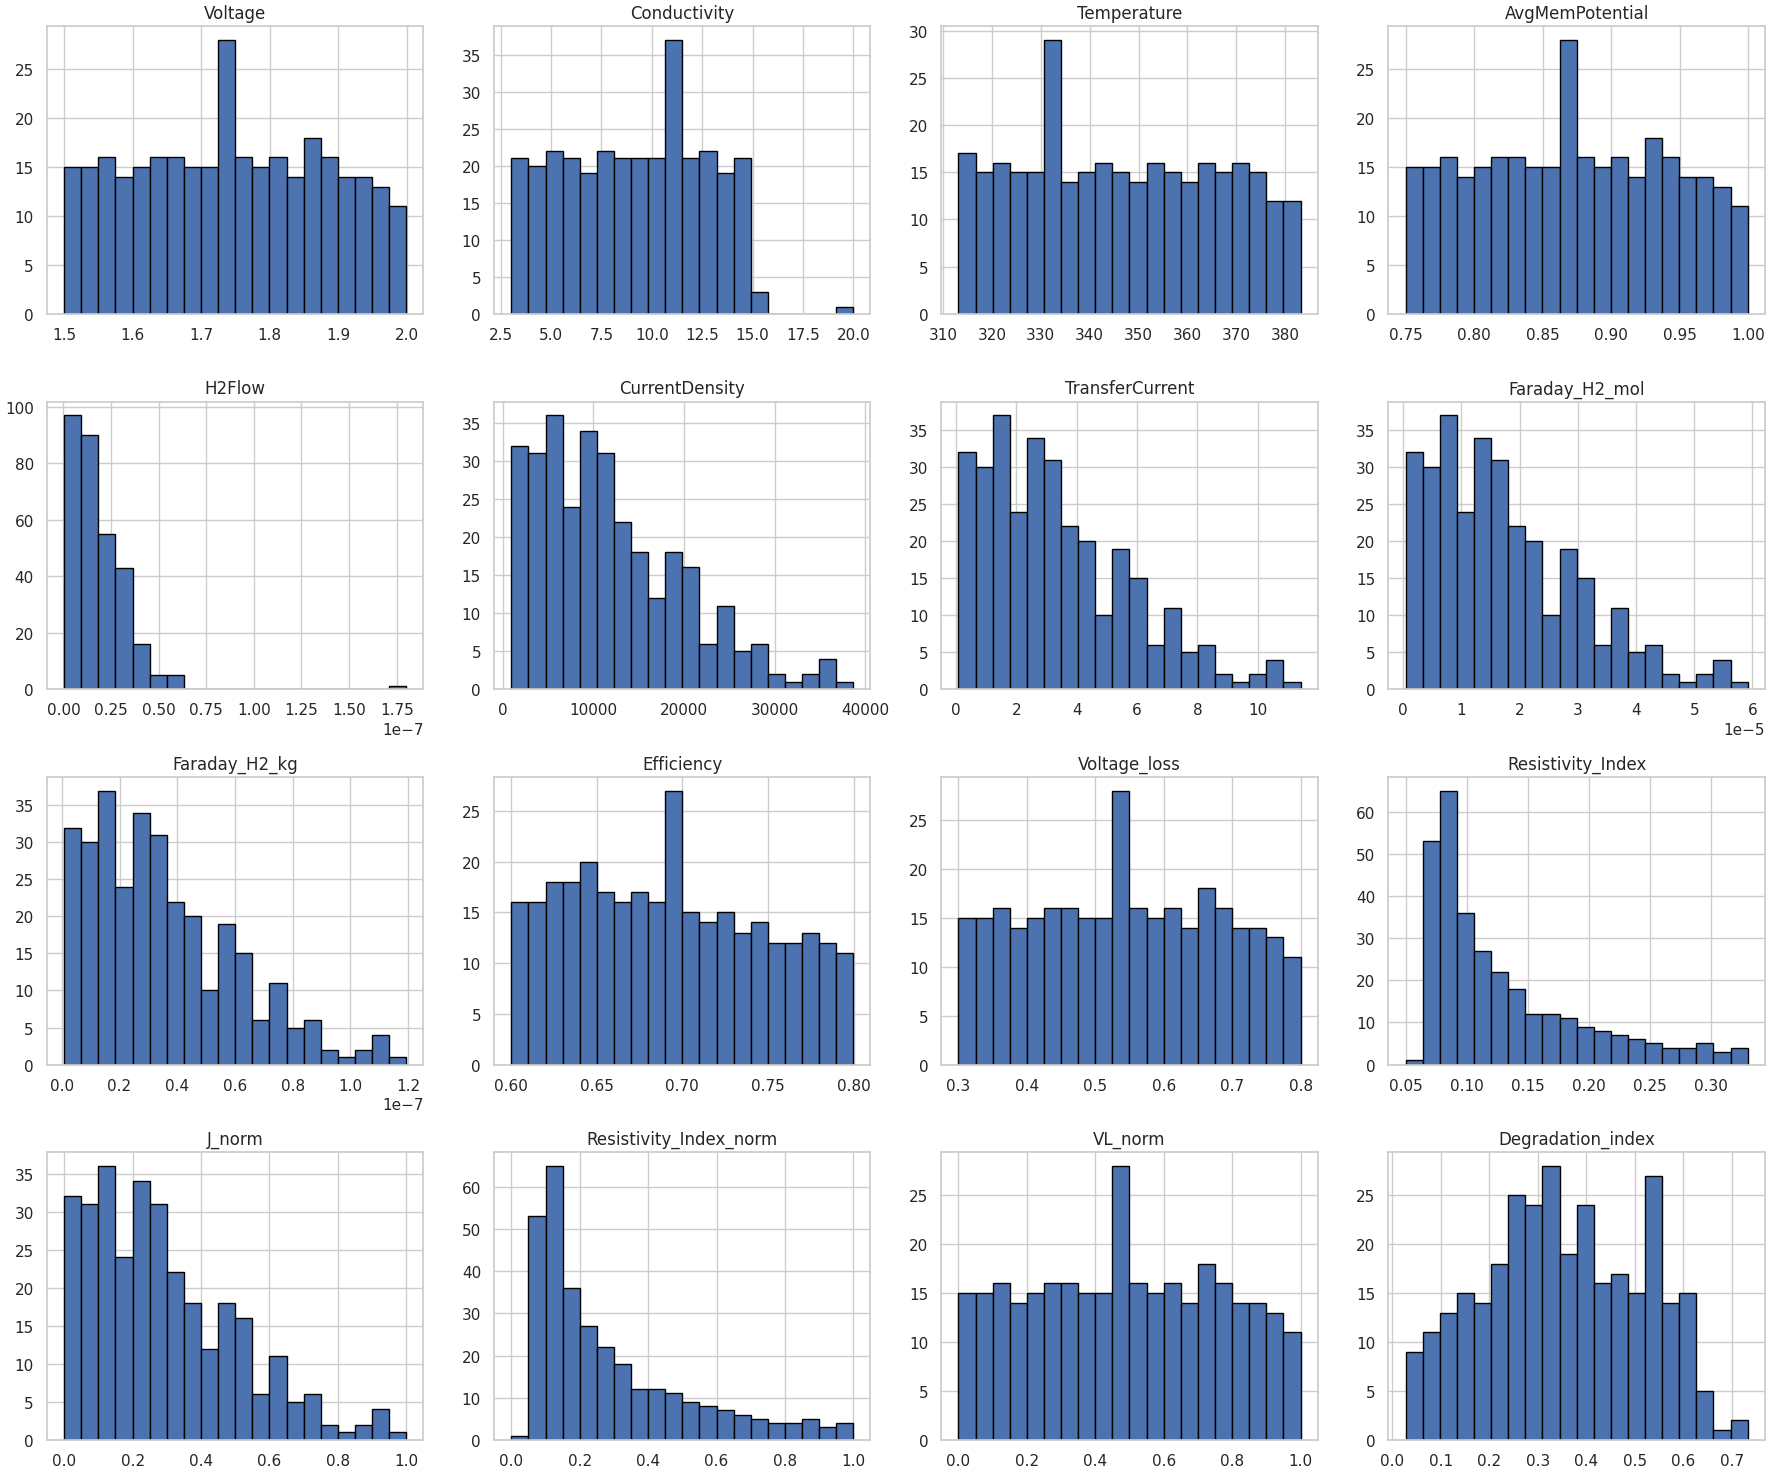

In [10]:
numeric_cols = df.select_dtypes(include='number').columns

df[numeric_cols].hist(
    figsize=(18,15),
    bins=20,
    edgecolor='black'
)

plt.tight_layout()

plt.show()

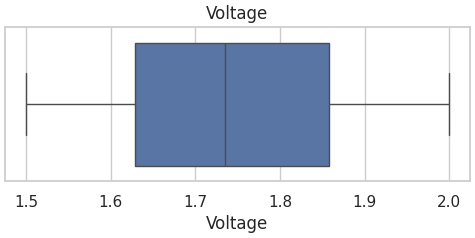

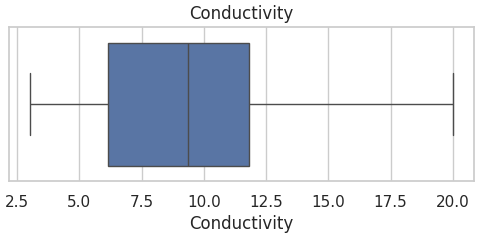

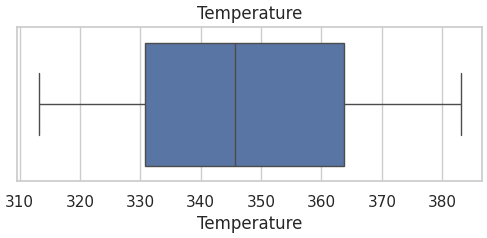

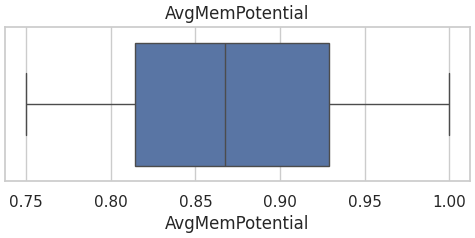

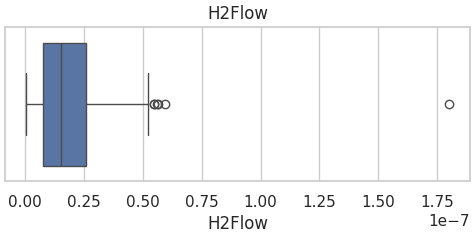

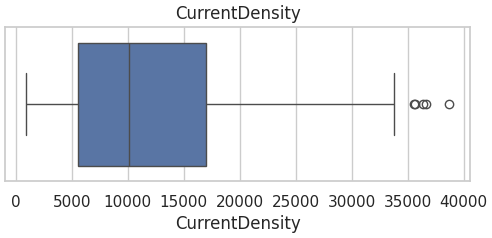

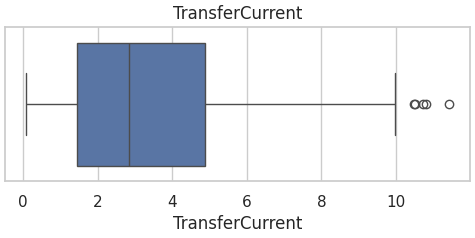

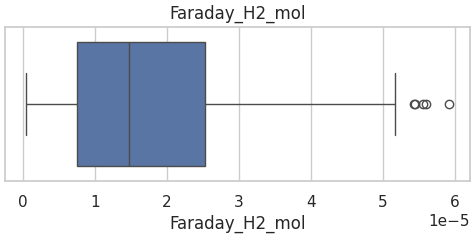

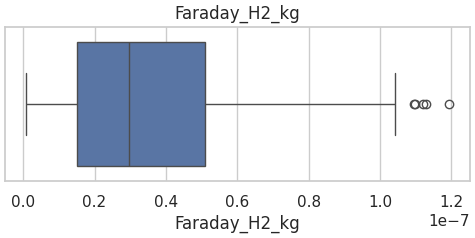

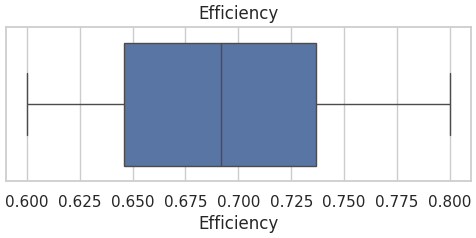

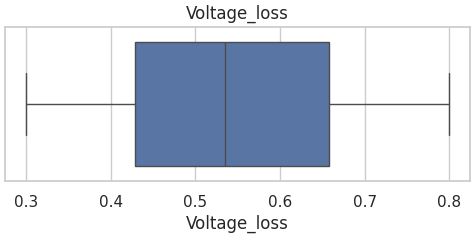

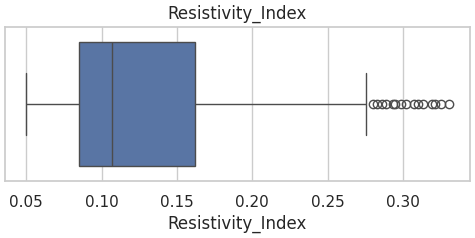

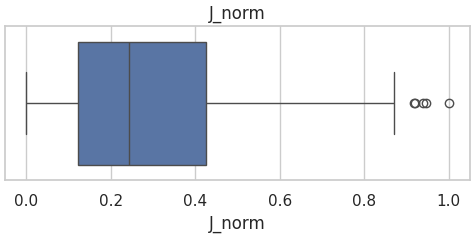

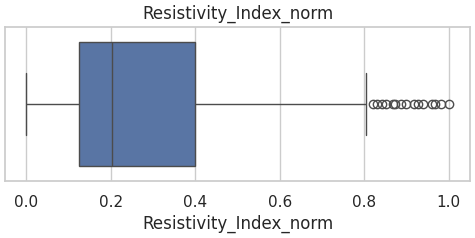

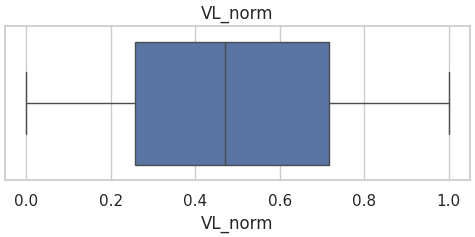

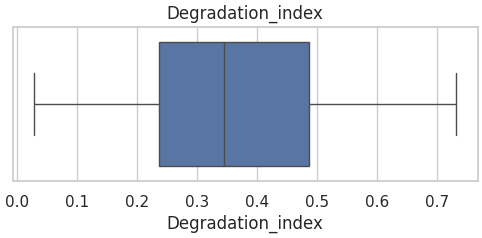

In [11]:
for col in numeric_cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

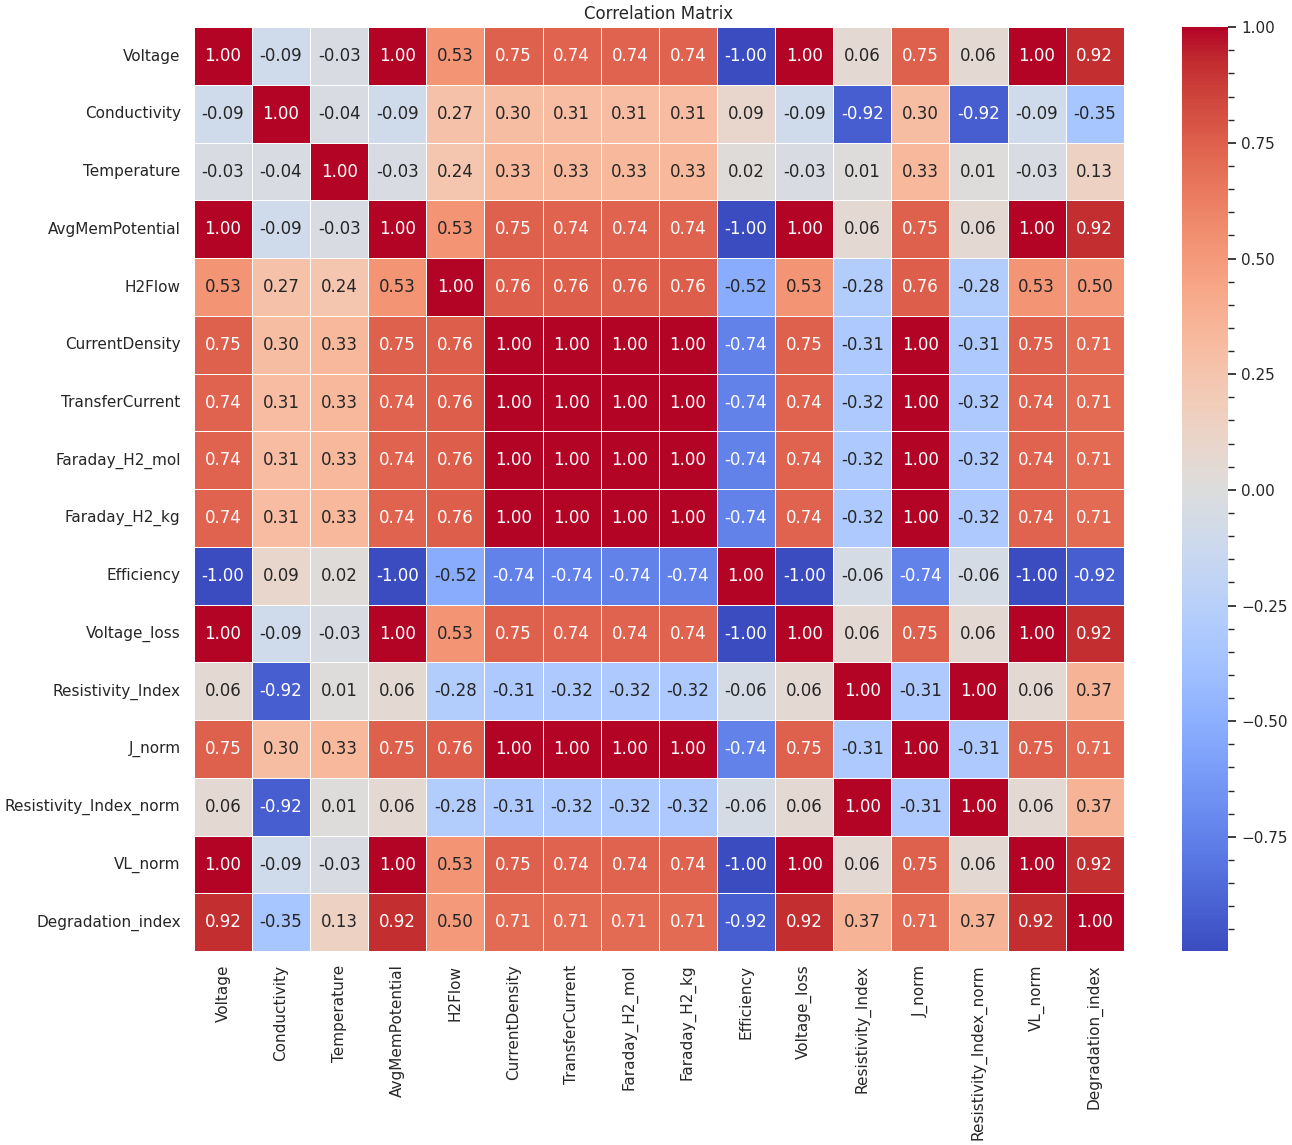

In [12]:
plt.figure(figsize=(15,12))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [13]:
corr["AvgMemPotential"].sort_values(
    ascending=False
)

,AvgMemPotential
AvgMemPotential,1.000000
VL_norm,1.000000
Voltage,1.000000
Voltage_loss,1.000000
Degradation_index,0.919228
CurrentDensity,0.746626
J_norm,0.746626
Faraday_H2_mol,0.741472
TransferCurrent,0.741472
Faraday_H2_kg,0.741472


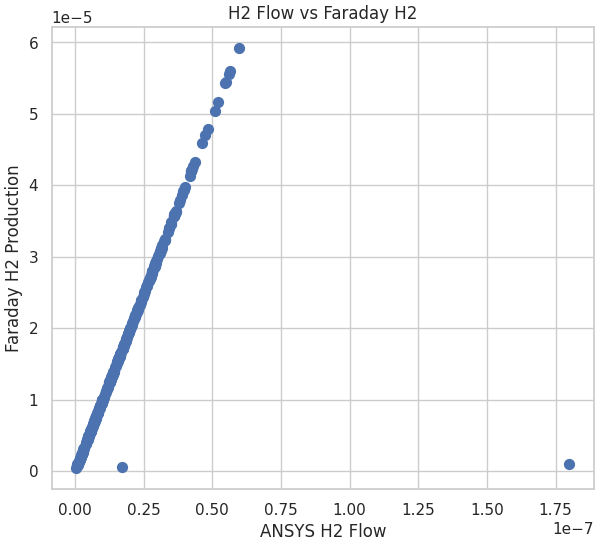

In [14]:
plt.figure(figsize=(7,6))

plt.scatter(
    df["H2Flow"],
    df["Faraday_H2_mol"],
    s=50
)

plt.xlabel("ANSYS H2 Flow")

plt.ylabel("Faraday H2 Production")

plt.title("H2 Flow vs Faraday H2")

plt.grid(True)

plt.show()

In [15]:
targets = [
    "Faraday_H2_mol",
    "Efficiency",
    "Voltage_loss",
    "Degradation_index"
]

for target in targets:

    print("="*50)

    print(target)

    print("="*50)

    print(
        corr[target].sort_values(
            ascending=False
        )
    )

    print("\n")

Faraday_H2_mol
TransferCurrent           1.000000
Faraday_H2_kg             1.000000
Faraday_H2_mol            1.000000
J_norm                    0.999960
CurrentDensity            0.999960
H2Flow                    0.756572
VL_norm                   0.741473
Voltage                   0.741473
Voltage_loss              0.741473
AvgMemPotential           0.741472
Degradation_index         0.705366
Temperature               0.334348
Conductivity              0.308511
Resistivity_Index_norm   -0.317776
Resistivity_Index        -0.317776
Efficiency               -0.739916
Name: Faraday_H2_mol, dtype: float64


Efficiency
Efficiency                1.000000
Conductivity              0.094248
Temperature               0.022897
Resistivity_Index_norm   -0.060370
Resistivity_Index        -0.060370
H2Flow                   -0.520809
Faraday_H2_kg            -0.739916
TransferCurrent          -0.739916
Faraday_H2_mol           -0.739916
J_norm                   -0.744941
CurrentDensity           

In [16]:
# ===============================
# Input Features
# ===============================

X = df[["Temperature", "Voltage", "Conductivity"]]

# Target Variables
y_H2 = df["Faraday_H2_mol"]
y_eff = df["Efficiency"]
y_vloss = df["Voltage_loss"]
y_deg = df["Degradation_index"]

print("Input Features:")
display(X.head())

print("\nTargets:")
print("H2 Production")
display(y_H2.head())

Input Features:


,Temperature,Voltage,Conductivity
0,314.22,1.8548,12.803
1,372.23,1.8768,11.581
2,330.55,1.9396,4.033
3,336.98,1.5930,7.470
4,325.91,1.7273,8.354



Targets:
H2 Production


,Faraday_H2_mol
0,0.000006
1,0.000042
2,0.000016
3,0.000005
4,0.000012


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=42
)

yH2_train, yH2_test = train_test_split(
    y_H2,
    test_size=0.20,
    random_state=42
)

yEff_train, yEff_test = train_test_split(
    y_eff,
    test_size=0.20,
    random_state=42
)

yVL_train, yVL_test = train_test_split(
    y_vloss,
    test_size=0.20,
    random_state=42
)

yDeg_train, yDeg_test = train_test_split(
    y_deg,
    test_size=0.20,
    random_state=42
)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_H2 = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_H2.fit(X_train, yH2_train)

print("Random Forest model for H2 trained successfully!")

Random Forest model for H2 trained successfully!


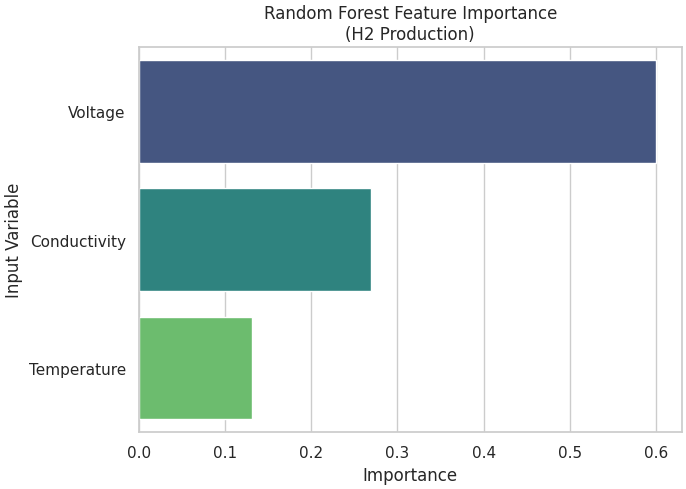

,Feature,Importance
1,Voltage,0.599632
2,Conductivity,0.268907
0,Temperature,0.131461


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_H2.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(7,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Random Forest Feature Importance\n(H2 Production)")

plt.xlabel("Importance")

plt.ylabel("Input Variable")

plt.show()

display(importance)

In [20]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, root_mean_squared_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cv = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

scoring = {
    "R2": "r2",
    "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
    "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False)
}

cv_results = cross_validate(
    rf_cv,
    X,
    y_H2,
    cv=kf,
    scoring=scoring,
    n_jobs=-1
)

print("="*60)
print("Random Forest - 5 Fold Cross Validation")
print("="*60)
print(f"Mean R²   : {cv_results['test_R2'].mean():.4f} ± {cv_results['test_R2'].std():.4f}")
print(f"Mean MAE  : {-cv_results['test_MAE'].mean():.6f} ± {cv_results['test_MAE'].std():.6f}")
print(f"Mean RMSE : {-cv_results['test_RMSE'].mean():.6f} ± {cv_results['test_RMSE'].std():.6f}")

Random Forest - 5 Fold Cross Validation
Mean R²   : 0.9418 ± 0.0548
Mean MAE  : 0.000002 ± 0.000000
Mean RMSE : 0.000003 ± 0.000001


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [22]:
# ==========================
# INPUT FEATURES
# ==========================

X = df[[
    "Temperature",
    "Voltage",
    "Conductivity"
]]

# ==========================
# TARGET VARIABLE
# ==========================

y = df["Faraday_H2_mol"]

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

display(X.head())
display(y.head())

Input Shape : (312, 3)
Output Shape: (312,)


,Temperature,Voltage,Conductivity
0,314.22,1.8548,12.803
1,372.23,1.8768,11.581
2,330.55,1.9396,4.033
3,336.98,1.5930,7.470
4,325.91,1.7273,8.354


,Faraday_H2_mol
0,0.000006
1,0.000042
2,0.000016
3,0.000005
4,0.000012


In [23]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

In [24]:
rf_H2 = RandomForestRegressor(

    n_estimators=500,

    random_state=42,

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=1

)

rf_H2.fit(

    X_train,

    y_train

)

print("Random Forest Model Successfully Trained")

Random Forest Model Successfully Trained


In [25]:
y_pred = rf_H2.predict(

    X_test

)
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": y_pred

})

comparison.head(10)

,Actual,Predicted
0,0.000015,0.000016
1,0.000029,0.000028
2,0.000012,0.000012
3,0.000014,0.000014
4,0.000019,0.000021
5,0.000012,0.000014
6,0.000029,0.000028
7,0.000007,0.000009
8,0.000016,0.000018
9,0.000010,0.000010


In [26]:
R2 = r2_score(

    y_test,

    y_pred

)

MAE = mean_absolute_error(

    y_test,

    y_pred

)

RMSE = np.sqrt(

    mean_squared_error(

        y_test,

        y_pred

    )

)

print("="*40)

print("Random Forest Performance")

print("="*40)

print(f"R²    : {R2:.5f}")

print(f"MAE   : {MAE:.6f}")

print(f"RMSE  : {RMSE:.6f}")

Random Forest Performance
R²    : 0.82100
MAE   : 0.000002
RMSE  : 0.000005


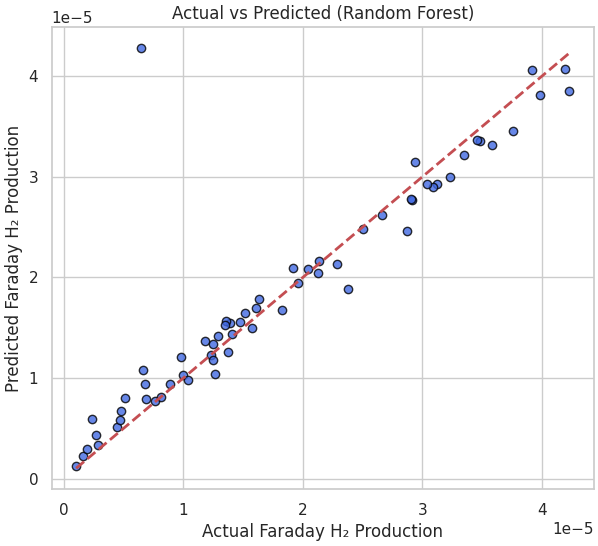

In [27]:
plt.figure(figsize=(7,6))

plt.scatter(

    y_test,

    y_pred,

    color="royalblue",

    edgecolor="black",

    alpha=0.8

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    'r--',

    linewidth=2

)

plt.xlabel("Actual Faraday H₂ Production")

plt.ylabel("Predicted Faraday H₂ Production")

plt.title("Actual vs Predicted (Random Forest)")

plt.grid(True)

plt.show()

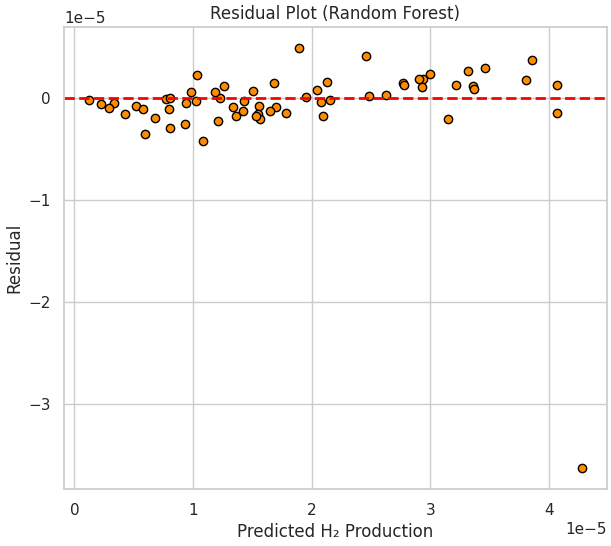

In [28]:
residuals = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(

    y_pred,

    residuals,

    color="darkorange",

    edgecolor="black"

)

plt.axhline(

    0,

    color="red",

    linestyle="--",

    linewidth=2

)

plt.xlabel("Predicted H₂ Production")

plt.ylabel("Residual")

plt.title("Residual Plot (Random Forest)")

plt.grid(True)

plt.show()

In [29]:
import joblib

joblib.dump(

    rf_H2,

    "RF_H2_Model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [30]:
comparison.to_csv(

    "RF_H2_Predictions.csv",

    index=False

)

comparison.head()

,Actual,Predicted
0,0.000015,0.000016
1,0.000029,0.000028
2,0.000012,0.000012
3,0.000014,0.000014
4,0.000019,0.000021


In [31]:
# ===============================
# Task 5
# Random Forest for Efficiency
# ===============================

X = df[["Temperature", "Voltage", "Conductivity"]]

y = df["Efficiency"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [33]:
rf_eff = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_eff.fit(X_train, y_train)

y_pred = rf_eff.predict(X_test)

In [34]:
R2 = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

print("Efficiency Model")
print("----------------")
print(f"R²   : {R2:.5f}")
print(f"MAE  : {MAE:.6f}")
print(f"RMSE : {RMSE:.6f}")

Efficiency Model
----------------
R²   : 0.99988
MAE  : 0.000405
RMSE : 0.000563


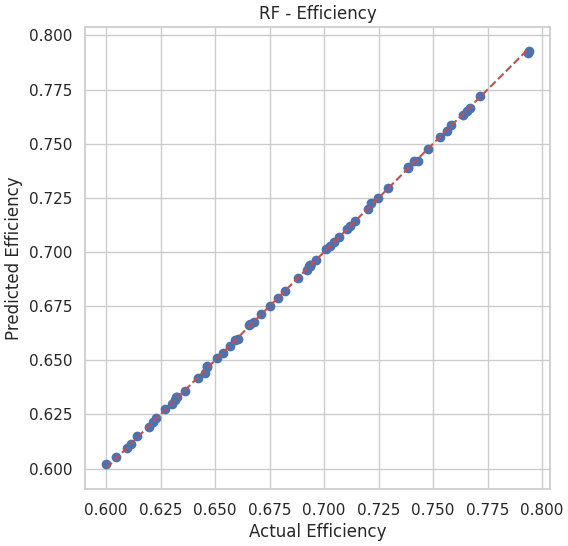

In [35]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Efficiency")
plt.ylabel("Predicted Efficiency")
plt.title("RF - Efficiency")

plt.show()

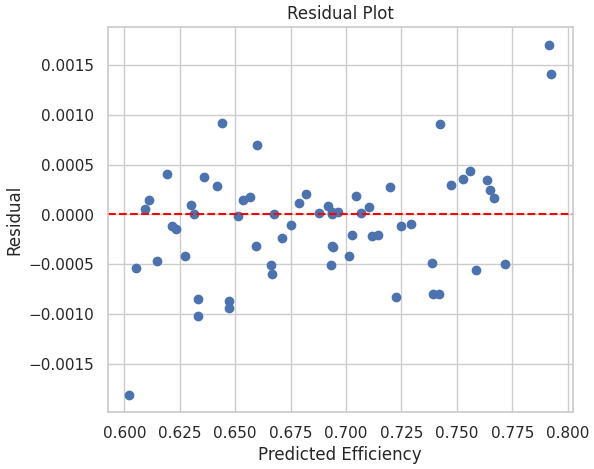

In [36]:
residual = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, residual)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Predicted Efficiency")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [37]:
X = df[["Temperature","Voltage","Conductivity"]]

y = df["Voltage_loss"]

In [38]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
rf_vloss = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_vloss.fit(X_train,y_train)

y_pred = rf_vloss.predict(X_test)

In [40]:
R2 = r2_score(y_test,y_pred)
MAE = mean_absolute_error(y_test,y_pred)
RMSE = np.sqrt(mean_squared_error(y_test,y_pred))

print("Voltage Loss Model")
print("----------------")

print(f"R²   : {R2:.5f}")
print(f"MAE  : {MAE:.6f}")
print(f"RMSE : {RMSE:.6f}")

Voltage Loss Model
----------------
R²   : 0.99987
MAE  : 0.001094
RMSE : 0.001477


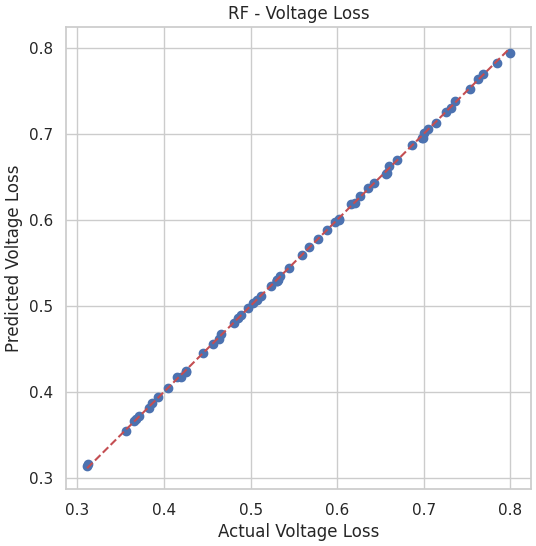

In [41]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred)

plt.plot(
[y_test.min(),y_test.max()],
[y_test.min(),y_test.max()],
'r--'
)

plt.xlabel("Actual Voltage Loss")

plt.ylabel("Predicted Voltage Loss")

plt.title("RF - Voltage Loss")

plt.show()

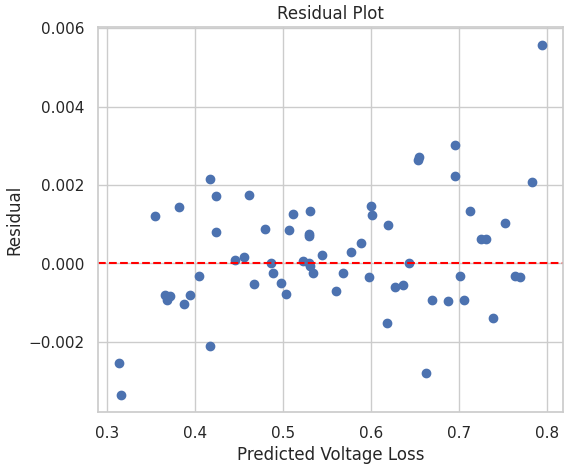

In [42]:
residual = y_test-y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred,residual)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Predicted Voltage Loss")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [43]:
X = df[["Temperature","Voltage","Conductivity"]]

y = df["Degradation_index"]

In [44]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [45]:
rf_deg = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

rf_deg.fit(X_train,y_train)

y_pred = rf_deg.predict(X_test)

In [46]:
R2 = r2_score(y_test,y_pred)
MAE = mean_absolute_error(y_test,y_pred)
RMSE = np.sqrt(mean_squared_error(y_test,y_pred))

print("Degradation Model")
print("----------------")

print(f"R²   : {R2:.5f}")
print(f"MAE  : {MAE:.6f}")
print(f"RMSE : {RMSE:.6f}")

Degradation Model
----------------
R²   : 0.97256
MAE  : 0.018014
RMSE : 0.023673


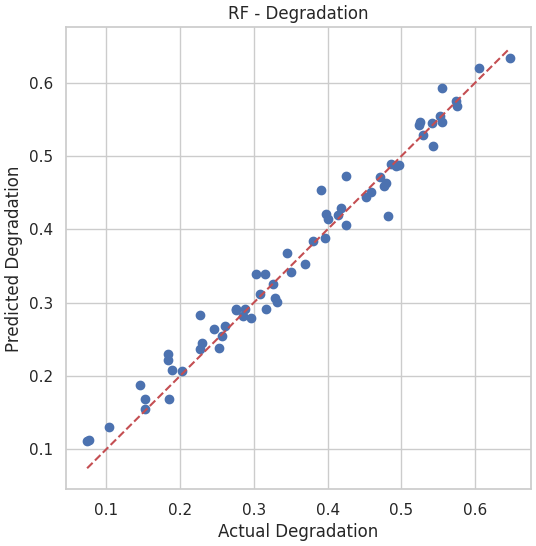

In [47]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred)

plt.plot(
[y_test.min(),y_test.max()],
[y_test.min(),y_test.max()],
'r--'
)

plt.xlabel("Actual Degradation")

plt.ylabel("Predicted Degradation")

plt.title("RF - Degradation")

plt.show()

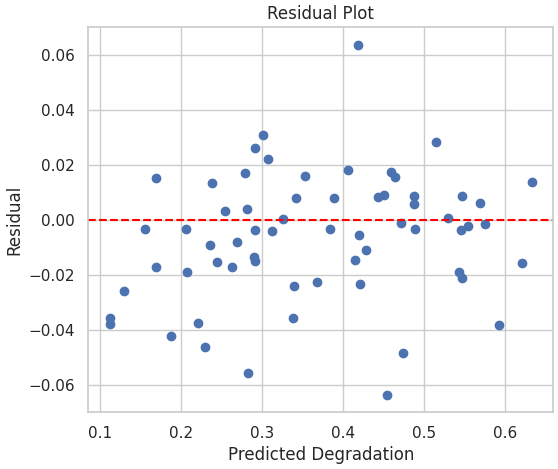

In [48]:
residual = y_test-y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred,residual)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Predicted Degradation")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [49]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel
)

In [50]:
kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=1.0)
    + WhiteKernel(noise_level=1e-5)
)

In [51]:
X = df[["Temperature", "Voltage", "Conductivity"]]

y = df["Faraday_H2_mol"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

gpr_H2 = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=42
)

gpr_H2.fit(X_train, y_train)

y_pred = gpr_H2.predict(X_test)

In [52]:
R2_H2 = r2_score(y_test, y_pred)
MAE_H2 = mean_absolute_error(y_test, y_pred)
RMSE_H2 = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== H₂ Production =====")
print(f"R²   : {R2_H2:.5f}")
print(f"MAE  : {MAE_H2:.6f}")
print(f"RMSE : {RMSE_H2:.6f}")

===== H₂ Production =====
R²   : 0.03579
MAE  : 0.000009
RMSE : 0.000011


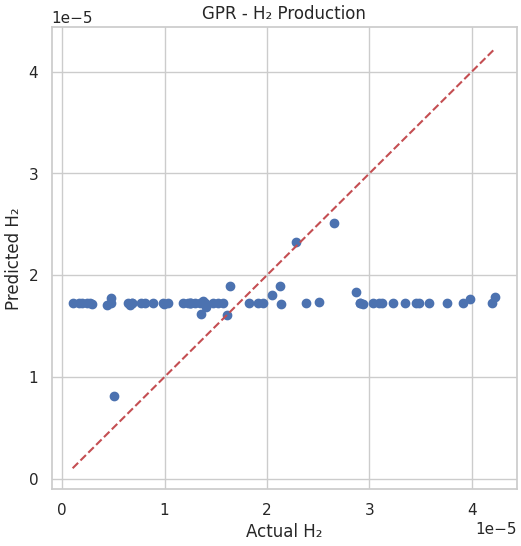

In [53]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual H₂")

plt.ylabel("Predicted H₂")

plt.title("GPR - H₂ Production")

plt.show()

In [54]:
y = df["Efficiency"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

gpr_eff = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=42
)

gpr_eff.fit(X_train, y_train)

y_pred = gpr_eff.predict(X_test)

R2_EFF = r2_score(y_test, y_pred)
MAE_EFF = mean_absolute_error(y_test, y_pred)
RMSE_EFF = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== Efficiency =====")
print(f"R²   : {R2_EFF:.5f}")
print(f"MAE  : {MAE_EFF:.6f}")
print(f"RMSE : {RMSE_EFF:.6f}")

===== Efficiency =====
R²   : -0.02112
MAE  : 0.042936
RMSE : 0.051397


In [55]:
y = df["Voltage_loss"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

gpr_vloss = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=42
)

gpr_vloss.fit(X_train, y_train)

y_pred = gpr_vloss.predict(X_test)

R2_VL = r2_score(y_test, y_pred)
MAE_VL = mean_absolute_error(y_test, y_pred)
RMSE_VL = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== Voltage Loss =====")
print(f"R²   : {R2_VL:.5f}")
print(f"MAE  : {MAE_VL:.6f}")
print(f"RMSE : {RMSE_VL:.6f}")

===== Voltage Loss =====
R²   : -0.02500
MAE  : 0.109580
RMSE : 0.130745


In [56]:
y = df["Degradation_index"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

gpr_deg = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    random_state=42
)

gpr_deg.fit(X_train, y_train)

y_pred = gpr_deg.predict(X_test)

R2_DEG = r2_score(y_test, y_pred)
MAE_DEG = mean_absolute_error(y_test, y_pred)
RMSE_DEG = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== Degradation =====")
print(f"R²   : {R2_DEG:.5f}")
print(f"MAE  : {MAE_DEG:.6f}")
print(f"RMSE : {RMSE_DEG:.6f}")

===== Degradation =====
R²   : 0.00674
MAE  : 0.119605
RMSE : 0.142426


In [57]:
comparison = pd.DataFrame({

    "Target":[
        "H₂ Production",
        "Efficiency",
        "Voltage Loss",
        "Degradation"
    ],

    "GPR_R2":[
        R2_H2,
        R2_EFF,
        R2_VL,
        R2_DEG
    ],

    "GPR_MAE":[
        MAE_H2,
        MAE_EFF,
        MAE_VL,
        MAE_DEG
    ],

    "GPR_RMSE":[
        RMSE_H2,
        RMSE_EFF,
        RMSE_VL,
        RMSE_DEG
    ]

})

comparison

,Target,GPR_R2,GPR_MAE,GPR_RMSE
0,H₂ Production,0.035786,0.000009,0.000011
1,Efficiency,-0.021118,0.042936,0.051397
2,Voltage Loss,-0.025003,0.109580,0.130745
3,Degradation,0.006737,0.119605,0.142426


In [58]:
print("="*60)
print("GAUSSIAN PROCESS REGRESSION PERFORMANCE")
print("="*60)

display(comparison)

print("\nModel Performance Summary")

for i in range(len(comparison)):
    print(f"\n{comparison.loc[i,'Target']}")
    print(f"R²   : {comparison.loc[i,'GPR_R2']:.5f}")
    print(f"MAE  : {comparison.loc[i,'GPR_MAE']:.6f}")
    print(f"RMSE : {comparison.loc[i,'GPR_RMSE']:.6f}")

GAUSSIAN PROCESS REGRESSION PERFORMANCE


,Target,GPR_R2,GPR_MAE,GPR_RMSE
0,H₂ Production,0.035786,0.000009,0.000011
1,Efficiency,-0.021118,0.042936,0.051397
2,Voltage Loss,-0.025003,0.109580,0.130745
3,Degradation,0.006737,0.119605,0.142426



Model Performance Summary

H₂ Production
R²   : 0.03579
MAE  : 0.000009
RMSE : 0.000011

Efficiency
R²   : -0.02112
MAE  : 0.042936
RMSE : 0.051397

Voltage Loss
R²   : -0.02500
MAE  : 0.109580
RMSE : 0.130745

Degradation
R²   : 0.00674
MAE  : 0.119605
RMSE : 0.142426


In [59]:
comparison.to_csv(
    "GPR_Model_Performance.csv",
    index=False
)

print("GPR comparison table saved successfully!")

GPR comparison table saved successfully!


In [60]:
import shap
shap.initjs()

In [61]:
feature_names = [
    "Temperature",
    "Voltage",
    "Conductivity"
]

X = df[feature_names]

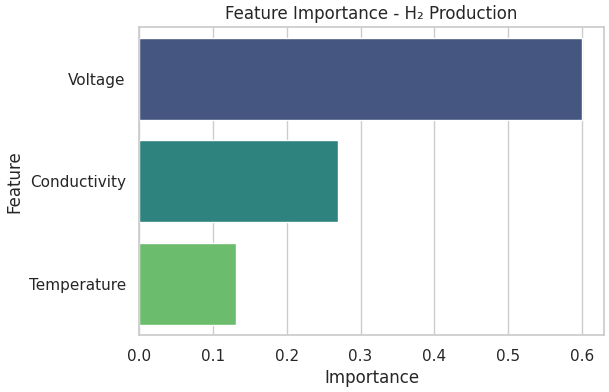

,Feature,Importance
1,Voltage,0.599632
2,Conductivity,0.268907
0,Temperature,0.131461


In [62]:
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":rf_H2.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("Feature Importance - H₂ Production")

plt.show()

display(importance)

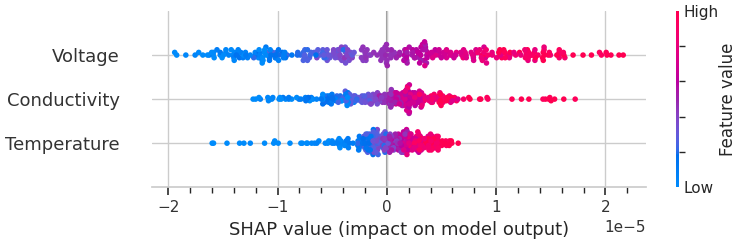

In [63]:
explainer = shap.TreeExplainer(rf_H2)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X,
    plot_type="dot"
)

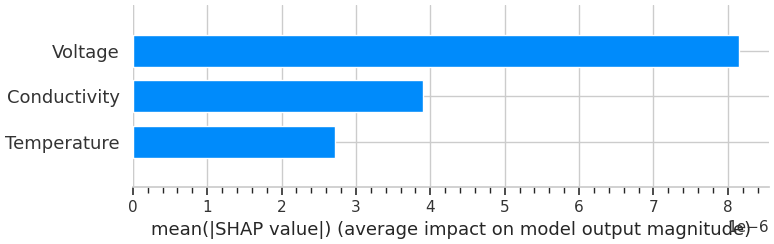

In [64]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

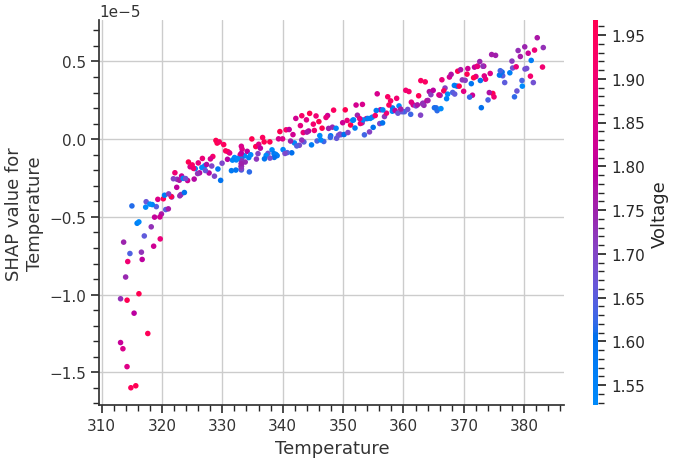

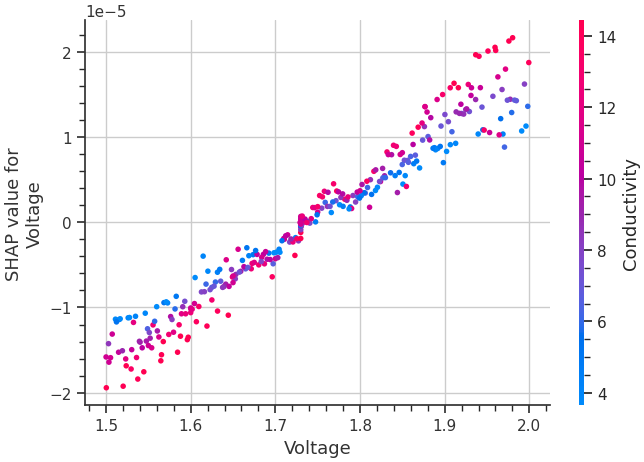

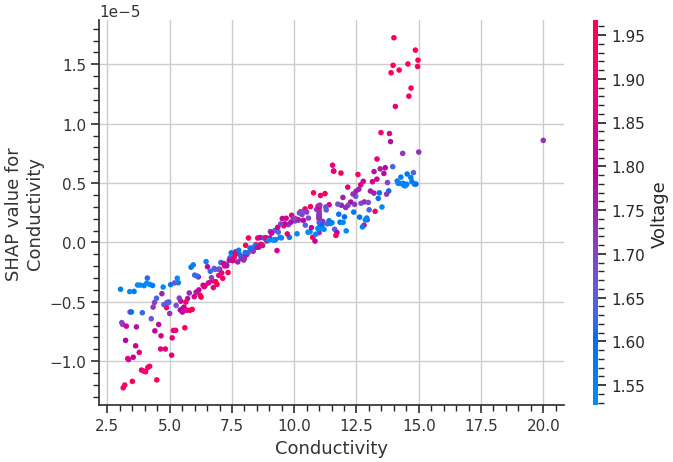

In [65]:
for feature in feature_names:

    shap.dependence_plot(
        feature,
        shap_values,
        X
    )

In [66]:
importance["Importance"].idxmax()

print("Most Influential Variable for H₂ Production")

print(importance.iloc[0])

Most Influential Variable for H₂ Production
Feature        Voltage
Importance    0.599632
Name: 1, dtype: object


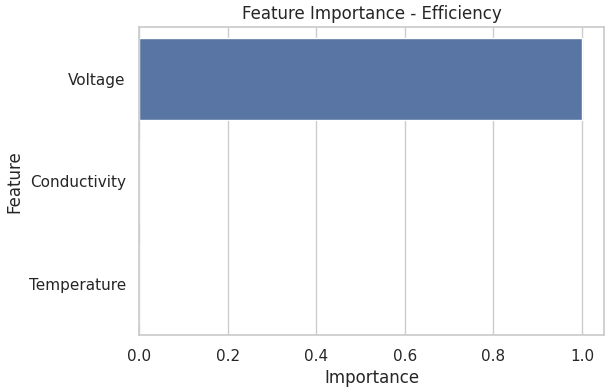

In [67]:
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":rf_eff.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Efficiency")

plt.show()

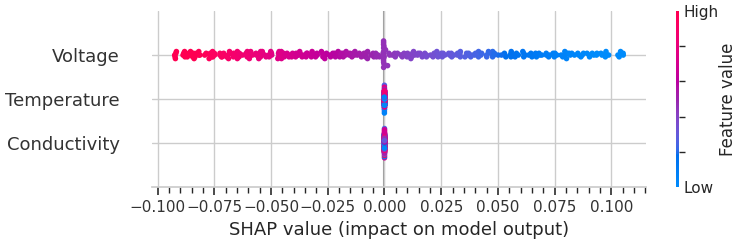

In [68]:
explainer = shap.TreeExplainer(rf_eff)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X
)

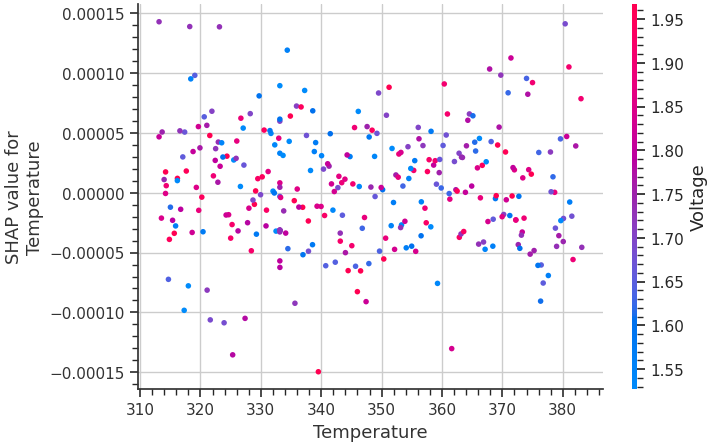

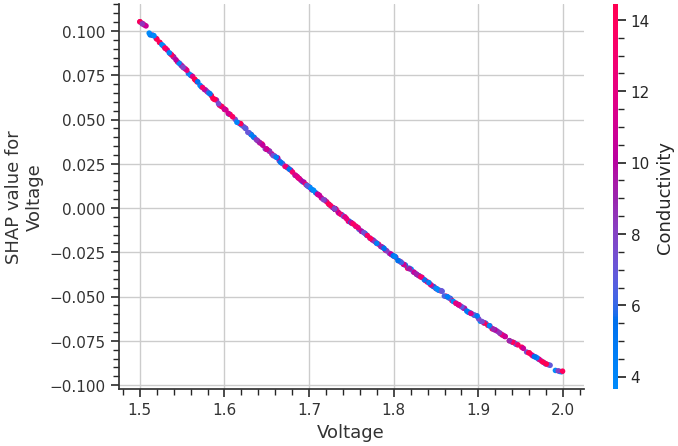

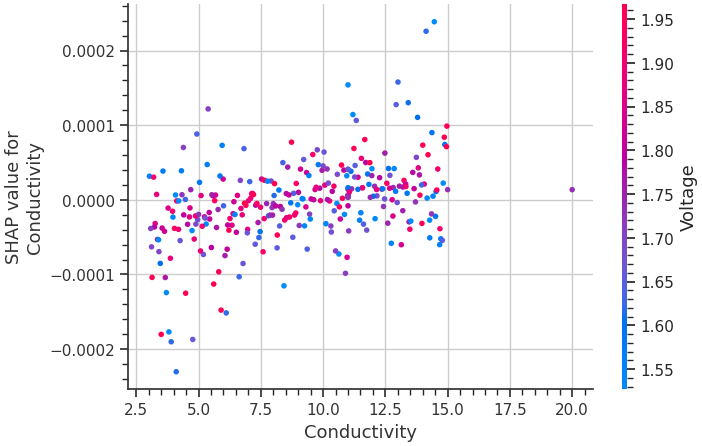

In [69]:
for feature in feature_names:

    shap.dependence_plot(
        feature,
        shap_values,
        X
    )

In [70]:
print("Most Influential Variable")

display(importance.iloc[0])

Most Influential Variable


,1
Feature,Voltage
Importance,0.999751


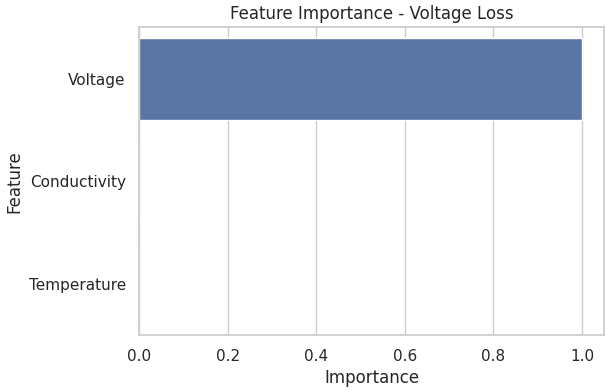

In [71]:
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":rf_vloss.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Voltage Loss")

plt.show()

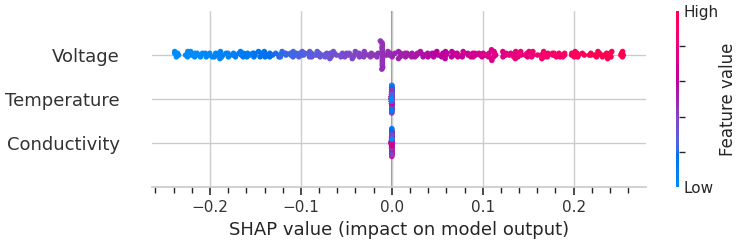

In [72]:
explainer = shap.TreeExplainer(rf_vloss)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X
)

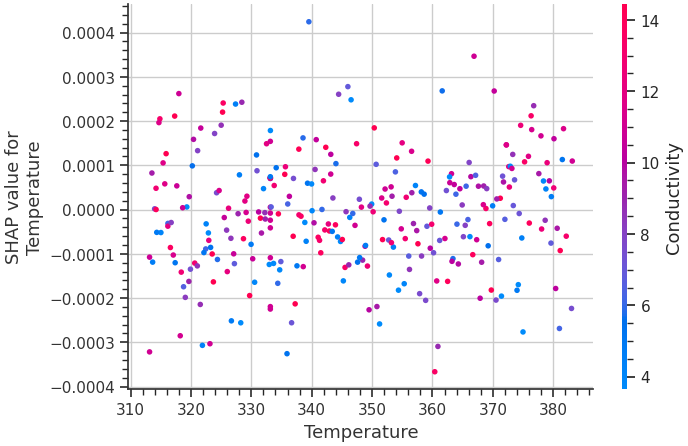

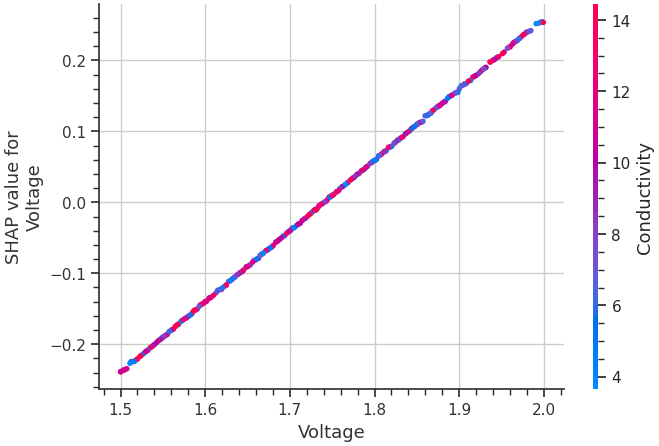

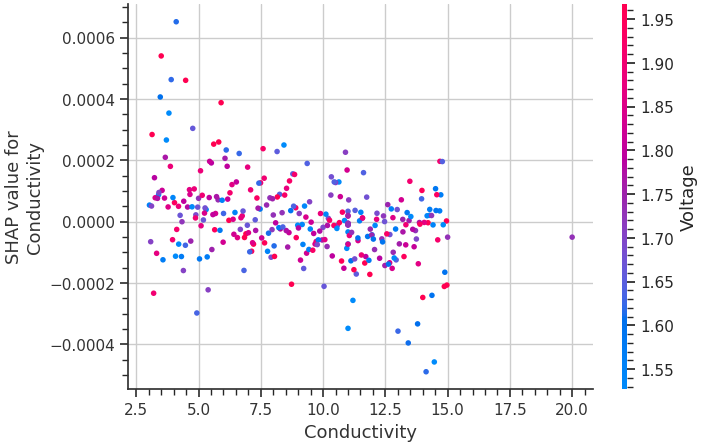

In [73]:
for feature in feature_names:

    shap.dependence_plot(
        feature,
        shap_values,
        X
    )

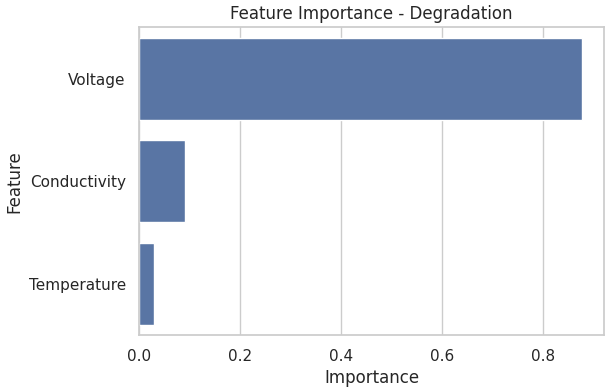

In [74]:
importance = pd.DataFrame({

    "Feature":feature_names,

    "Importance":rf_deg.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Degradation")

plt.show()

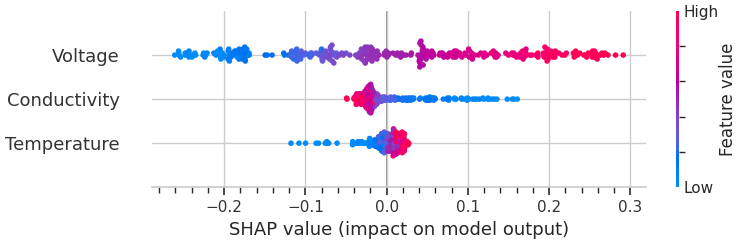

In [75]:
explainer = shap.TreeExplainer(rf_deg)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X
)

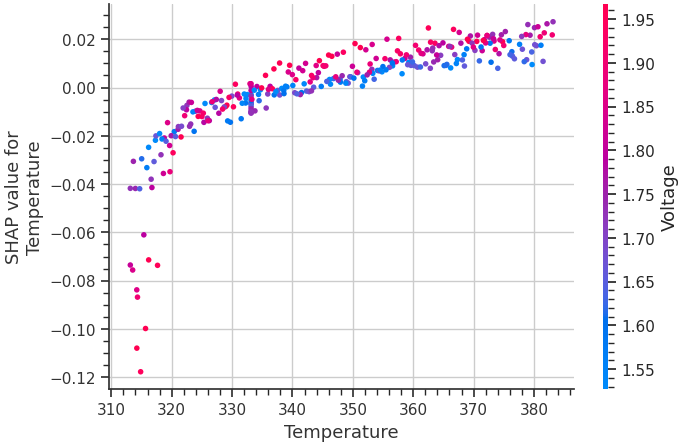

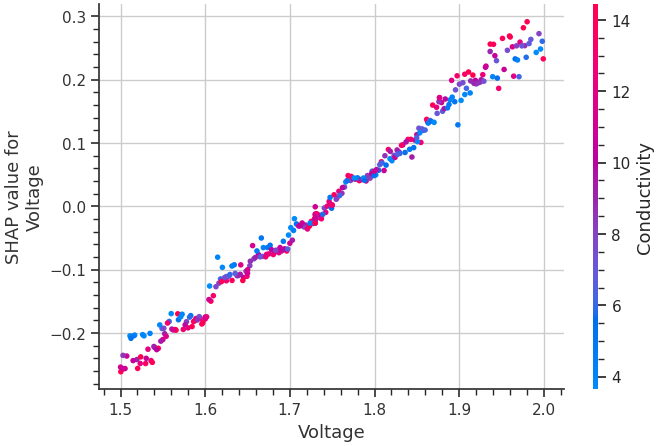

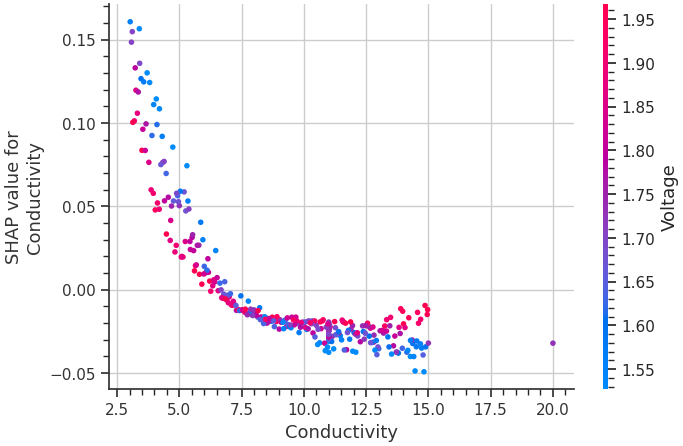

In [76]:
for feature in feature_names:

    shap.dependence_plot(
        feature,
        shap_values,
        X
    )

In [77]:
print("Most Influential Variable")

display(importance.iloc[0])

Most Influential Variable


,1
Feature,Voltage
Importance,0.877319


In [78]:
from pymoo.core.problem import Problem

from pymoo.algorithms.moo.nsga2 import NSGA2

from pymoo.optimize import minimize

import numpy as np

import matplotlib.pyplot as plt

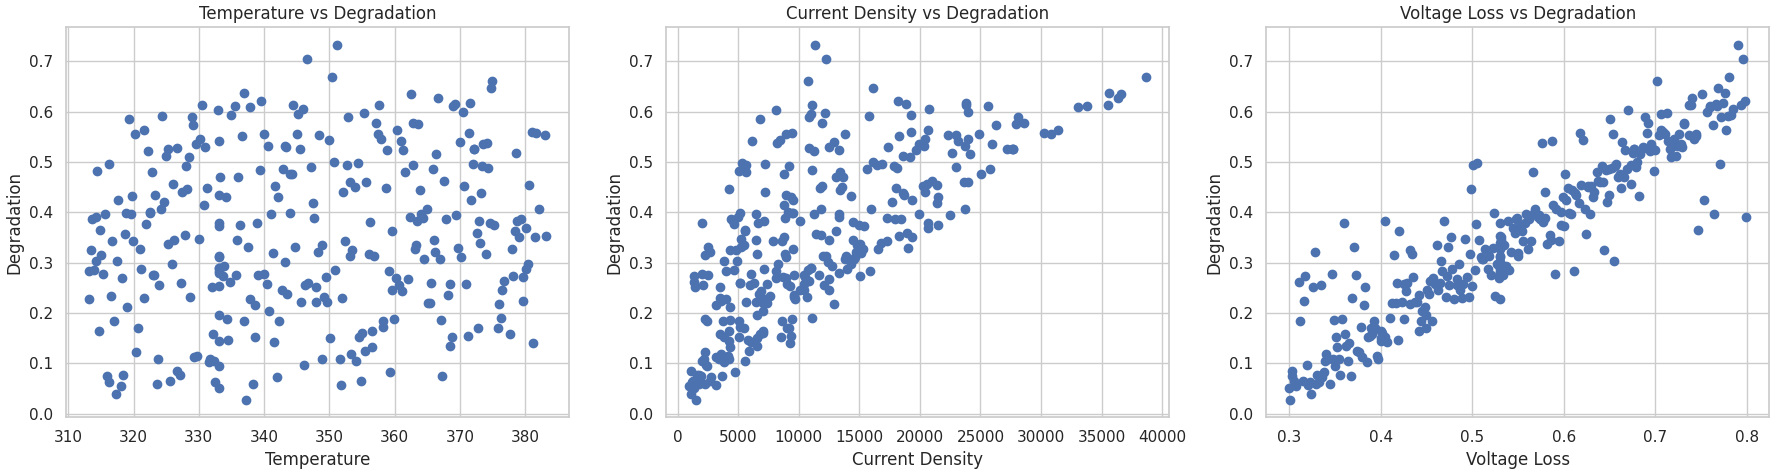

In [79]:
fig, ax = plt.subplots(1,3, figsize=(18,5))

# Temperature

ax[0].scatter(
    df["Temperature"],
    df["Degradation_index"]
)

ax[0].set_xlabel("Temperature")

ax[0].set_ylabel("Degradation")

ax[0].set_title("Temperature vs Degradation")

# Current Density

ax[1].scatter(
    df["CurrentDensity"],
    df["Degradation_index"]
)

ax[1].set_xlabel("Current Density")

ax[1].set_ylabel("Degradation")

ax[1].set_title("Current Density vs Degradation")

# Voltage Loss

ax[2].scatter(
    df["Voltage_loss"],
    df["Degradation_index"]
)

ax[2].set_xlabel("Voltage Loss")

ax[2].set_ylabel("Degradation")

ax[2].set_title("Voltage Loss vs Degradation")

plt.tight_layout()

plt.show()

In [80]:
lower = np.array([
    df["Temperature"].min(),
    df["Voltage"].min(),
    df["Conductivity"].min()
])

upper = np.array([
    df["Temperature"].max(),
    df["Voltage"].max(),
    df["Conductivity"].max()
])

print(lower)

print(upper)

[313.15    1.5     3.027]
[383.15     1.9994  20.    ]


In [81]:
import pandas as pd

excel_file = pd.ExcelFile("electrolyser_data.xlsx")

print(excel_file.sheet_names)

['Dataset', 'Test Data ', 'Test results Ansys ', 'Test resulst Model', 'External validation metrics', 'Dataset info', 'DOE points', 'Model metrics', 'Optimal Operating Cond', 'Pareto', 'Sensitivity Analysis', 'Metadata', 'CFD', 'Electrochemical Prop', 'Cell zone config', 'Materials', 'Derived Outputs']


In [82]:
import pandas as pd

df = pd.read_excel("electrolyser_data.xlsx")

print(df.head())
print(df.shape)

  Name   Voltage  Conductivity  Temperature  AvgMemPotential        H2Flow  \
0  DP 0   1.8548        12.803       314.22         0.927400  6.480000e-09   
1  DP 1   1.8768        11.581       372.23         0.938399  4.240000e-08   
2  DP 2   1.9396         4.033       330.55         0.969800  1.610000e-08   
3  DP 3   1.5930         7.470       336.98         0.796500  4.770000e-09   
4  DP 4   1.7273         8.354       325.91         0.863649  1.190000e-08   

   CurrentDensity  TransferCurrent  Faraday_H2_mol  Faraday_H2_kg  Efficiency  \
0       4898.0404         1.240041        0.000006   1.295499e-08    0.646916   
1      27710.4760         8.111412        0.000042   8.474171e-08    0.639333   
2      11119.3020         3.082441        0.000016   3.220294e-08    0.618633   
3       3724.0327         0.912700        0.000005   9.535180e-09    0.753233   
4       8277.5492         2.274325        0.000012   2.376037e-08    0.694668   

   Voltage_loss  Resistivity_Index    J_norm

In [83]:
X = df[["Temperature", "Voltage", "Conductivity"]]

In [84]:
y = df["Faraday_H2_mol"]

In [85]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)

import numpy as np

In [86]:
kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=1.0)
    + WhiteKernel(noise_level=1e-5)
)

gpr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    ))
])

In [87]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    gpr_pipeline,
    X,
    y,
    cv=kf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

In [88]:
print("="*40)
print("Gaussian Process Regression")
print("="*40)

print(f"Mean R²   : {cv_results['test_r2'].mean():.4f}")
print(f"Std R²    : {cv_results['test_r2'].std():.4f}")

print(f"Mean MAE  : {-cv_results['test_mae'].mean():.6f}")
print(f"Std MAE   : {cv_results['test_mae'].std():.6f}")

print(f"Mean RMSE : {-cv_results['test_rmse'].mean():.6f}")
print(f"Std RMSE  : {cv_results['test_rmse'].std():.6f}")

Gaussian Process Regression
Mean R²   : 0.9905
Std R²    : 0.0088
Mean MAE  : 0.000000
Std MAE   : 0.000000
Mean RMSE : 0.000001
Std RMSE  : 0.000001


In [89]:
y = df["Efficiency"]
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)

import numpy as np
kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=1.0)
    + WhiteKernel(noise_level=1e-5)
)

gpr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    ))
])
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    gpr_pipeline,
    X,
    y,
    cv=kf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)
print("="*40)
print("Gaussian Process Regression")
print("="*40)

print(f"Mean R²   : {cv_results['test_r2'].mean():.4f}")
print(f"Std R²    : {cv_results['test_r2'].std():.4f}")

print(f"Mean MAE  : {-cv_results['test_mae'].mean():.6f}")
print(f"Std MAE   : {cv_results['test_mae'].std():.6f}")

print(f"Mean RMSE : {-cv_results['test_rmse'].mean():.6f}")
print(f"Std RMSE  : {cv_results['test_rmse'].std():.6f}")

Gaussian Process Regression
Mean R²   : 1.0000
Std R²    : 0.0000
Mean MAE  : 0.000024
Std MAE   : 0.000002
Mean RMSE : 0.000030
Std RMSE  : 0.000003


In [90]:
y = df["Voltage_loss"]
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)

import numpy as np
kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=1.0)
    + WhiteKernel(noise_level=1e-5)
)

gpr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    ))
])
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    gpr_pipeline,
    X,
    y,
    cv=kf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)
print("="*40)
print("Gaussian Process Regression")
print("="*40)

print(f"Mean R²   : {cv_results['test_r2'].mean():.4f}")
print(f"Std R²    : {cv_results['test_r2'].std():.4f}")

print(f"Mean MAE  : {-cv_results['test_mae'].mean():.6f}")
print(f"Std MAE   : {cv_results['test_mae'].std():.6f}")

print(f"Mean RMSE : {-cv_results['test_rmse'].mean():.6f}")
print(f"Std RMSE  : {cv_results['test_rmse'].std():.6f}")

Gaussian Process Regression
Mean R²   : 1.0000
Std R²    : 0.0000
Mean MAE  : 0.000000
Std MAE   : 0.000000
Mean RMSE : 0.000000
Std RMSE  : 0.000000


In [91]:
y = df["Degradation_index"]
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)

import numpy as np
kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=1.0)
    + WhiteKernel(noise_level=1e-5)
)

gpr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        n_restarts_optimizer=10,
        random_state=42
    ))
])
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    gpr_pipeline,
    X,
    y,
    cv=kf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)
print("="*40)
print("Gaussian Process Regression")
print("="*40)

print(f"Mean R²   : {cv_results['test_r2'].mean():.4f}")
print(f"Std R²    : {cv_results['test_r2'].std():.4f}")

print(f"Mean MAE  : {-cv_results['test_mae'].mean():.6f}")
print(f"Std MAE   : {cv_results['test_mae'].std():.6f}")

print(f"Mean RMSE : {-cv_results['test_rmse'].mean():.6f}")
print(f"Std RMSE  : {cv_results['test_rmse'].std():.6f}")

Gaussian Process Regression
Mean R²   : 0.9951
Std R²    : 0.0078
Mean MAE  : 0.003361
Std MAE   : 0.001497
Mean RMSE : 0.008940
Std RMSE  : 0.008052


In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    ConstantKernel,
    WhiteKernel,
)

kernel = (
    ConstantKernel(1.0)
    * RBF(length_scale=1.0)
    + WhiteKernel(noise_level=1e-5)
)

def create_gpr():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("gpr", GaussianProcessRegressor(
            kernel=kernel,
            normalize_y=True,
            n_restarts_optimizer=10,
            random_state=42
        ))
    ])

In [93]:
X = df[["Temperature", "Voltage", "Conductivity"]]

In [94]:
gpr_h2 = create_gpr()
gpr_h2.fit(X, df["Faraday_H2_mol"])

Pipeline(steps=[('scaler', StandardScaler()),
                ('gpr',
                 GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05),
                                          n_restarts_optimizer=10,
                                          normalize_y=True, random_state=42))])

In [95]:
gpr_eff = create_gpr()
gpr_eff.fit(X, df["Efficiency"])

Pipeline(steps=[('scaler', StandardScaler()),
                ('gpr',
                 GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05),
                                          n_restarts_optimizer=10,
                                          normalize_y=True, random_state=42))])

In [96]:
gpr_deg = create_gpr()
gpr_deg.fit(X, df["Degradation_index"])

Pipeline(steps=[('scaler', StandardScaler()),
                ('gpr',
                 GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05),
                                          n_restarts_optimizer=10,
                                          normalize_y=True, random_state=42))])

In [97]:
gpr_vloss = create_gpr()
gpr_vloss.fit(X, df["Voltage_loss"])

Pipeline(steps=[('scaler', StandardScaler()),
                ('gpr',
                 GaussianProcessRegressor(kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05),
                                          n_restarts_optimizer=10,
                                          normalize_y=True, random_state=42))])

In [98]:
# Predict using the trained GPR model
y_pred, y_std = gpr_h2.predict(X, return_std=True)

In [99]:
results = pd.DataFrame({
    "Actual": df["Faraday_H2_mol"],
    "Predicted": y_pred,
    "Std_Dev": y_std
})

results["Lower_95CI"] = results["Predicted"] - 1.96 * results["Std_Dev"]
results["Upper_95CI"] = results["Predicted"] + 1.96 * results["Std_Dev"]

results.head()

,Actual,Predicted,Std_Dev,Lower_95CI,Upper_95CI
0,0.000006,0.000007,6.816276e-07,0.000005,0.000008
1,0.000042,0.000042,6.137498e-07,0.000041,0.000043
2,0.000016,0.000016,6.834509e-07,0.000015,0.000018
3,0.000005,0.000005,5.935509e-07,0.000004,0.000006
4,0.000012,0.000012,5.791558e-07,0.000011,0.000013


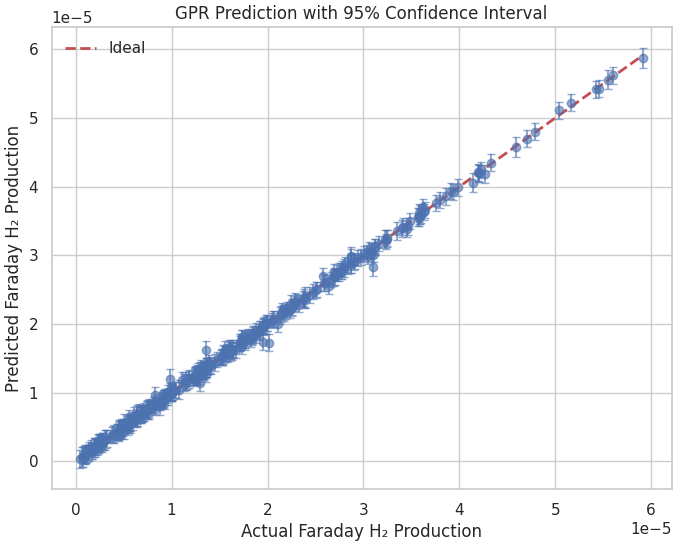

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.errorbar(
    results["Actual"],
    results["Predicted"],
    yerr=1.96*results["Std_Dev"],
    fmt='o',
    alpha=0.6,
    capsize=3
)

plt.plot(
    [results["Actual"].min(), results["Actual"].max()],
    [results["Actual"].min(), results["Actual"].max()],
    'r--',
    linewidth=2,
    label="Ideal"
)

plt.xlabel("Actual Faraday H₂ Production")
plt.ylabel("Predicted Faraday H₂ Production")
plt.title("GPR Prediction with 95% Confidence Interval")
plt.legend()

plt.show()

In [102]:
#External Validation
import pandas as pd

test_df = pd.read_csv(
    '/content/electrolyser_data - Test Data .csv'
)

test_df.head()

X_test = test_df[
    ["Temperature", "Voltage", "Conductivity"]
]
pred_h2, std_h2 = gpr_h2.predict(
    X_test,
    return_std=True
)

pred_eff, std_eff = gpr_eff.predict(
    X_test,
    return_std=True
)

pred_vloss, std_vloss = gpr_vloss.predict(
    X_test,
    return_std=True
)

pred_deg, std_deg = gpr_deg.predict(
    X_test,
    return_std=True
)
test_df["Pred_H2"] = pred_h2
test_df["Pred_Efficiency"] = pred_eff
test_df["Pred_VoltageLoss"] = pred_vloss
test_df["Pred_Degradation"] = pred_deg

test_df["Std_H2"] = std_h2
test_df["Std_Efficiency"] = std_eff
test_df["Std_VoltageLoss"] = std_vloss
test_df["Std_Degradation"] = std_deg

test_df.head()

,Voltage,Conductivity,Temperature,Pred_H2,Pred_Efficiency,Pred_VoltageLoss,Pred_Degradation,Std_H2,Std_Efficiency,Std_VoltageLoss,Std_Degradation
0,1.7631,8.670,316.77,0.000011,0.680542,0.5632,0.310490,5.912822e-07,0.000179,0.000441,0.003343
1,1.6730,3.205,329.60,0.000005,0.717222,0.4731,0.445079,7.698789e-07,0.000184,0.000444,0.004336
2,1.8711,4.248,344.54,0.000015,0.641300,0.6712,0.546791,5.863729e-07,0.000179,0.000441,0.003324
3,1.9174,11.030,351.50,0.000040,0.625822,0.7175,0.543150,6.349377e-07,0.000178,0.000440,0.003559
4,1.7429,12.514,319.31,0.000014,0.688431,0.5430,0.269850,5.965467e-07,0.000179,0.000441,0.003378


In [103]:
test_actual_df = pd.read_excel(
    "electrolyser_data.xlsx",
    sheet_name="Test results Ansys "
)

print("Actual test results loaded successfully.")
display(test_actual_df.head())

Actual test results loaded successfully.


,Name,Voltage,Conductivity,Temperature,AvgMemPotential,H2Flow,CurrentDensity,TransferCurrent,Faraday_H2_mol,Faraday_H2_kg,Efficiency,Voltage_loss,Resistivity_Index,J_norm,Resistivity_Index_norm,VL_norm,Degradation_index
0,DP 1,1.7631,8.670,316.77,0.881550,1.128053e-08,7922.2696,2.160362,0.000011,2.256978e-08,0.680563,0.5632,0.115340,0.245650,0.195373,0.526162,0.319171
1,DP 2,1.6730,3.205,329.60,0.836500,4.562691e-09,3654.3640,0.873648,0.000005,9.127193e-09,0.717215,0.4731,0.312012,0.096305,1.000000,0.338336,0.473432
2,DP 3,1.8711,4.248,344.54,0.935550,1.525393e-08,10549.1930,2.920769,0.000015,3.051391e-08,0.641281,0.6712,0.235405,0.337573,0.686583,0.751303,0.585901
3,DP 4,1.9174,11.030,351.50,0.958699,4.007519e-08,26265.1340,7.673406,0.000040,8.016576e-08,0.625795,0.7175,0.090662,0.887516,0.094409,0.847822,0.603816
4,DP 5,1.7429,12.514,319.31,0.871450,1.568575e-08,10646.0510,3.003421,0.000016,3.137740e-08,0.688450,0.5430,0.079911,0.340962,0.050423,0.484053,0.288894


In [104]:
test_df.to_csv(
    "external_validation_results.csv",
    index=False
)

print("External validation results saved successfully to 'external_validation_results.csv'")

External validation results saved successfully to 'external_validation_results.csv'


In [105]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

def evaluate_model(actual, predicted, target_name):

    r2 = r2_score(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Avoid divide-by-zero in MAPE
    actual = np.array(actual)
    predicted = np.array(predicted)

    mask = actual != 0
    mape = np.mean(np.abs((actual[mask]-predicted[mask])/actual[mask]))*100

    print("="*50)
    print(target_name)
    print("="*50)

    print(f"R²   : {r2:.4f}")
    print(f"MAE  : {mae:.6e}")
    print(f"RMSE : {rmse:.6e}")
    print(f"MAPE : {mape:.2f}%")

    return {
        "Target":target_name,
        "R²":r2,
        "MAE":mae,
        "RMSE":rmse,
        "MAPE":mape
    }

In [108]:
import pandas as pd

# Use the already loaded actual test results from the Excel file
actual_df = test_actual_df.copy()

# Load the predicted results from the CSV file saved earlier
pred_df = pd.read_csv("external_validation_results.csv")

print(actual_df.shape)
print(pred_df.shape)

(25, 17)
(25, 11)


In [109]:
validation_df = actual_df.copy()

validation_df["Pred_H2"] = pred_df["Pred_H2"]

validation_df["Pred_Efficiency"] = pred_df["Pred_Efficiency"]

validation_df["Pred_VoltageLoss"] = pred_df["Pred_VoltageLoss"]

validation_df["Pred_Degradation"] = pred_df["Pred_Degradation"]

In [110]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def evaluate(actual, pred):
    actual = np.array(actual)
    pred = np.array(pred)

    r2 = r2_score(actual, pred)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))

    mask = actual != 0
    if np.any(mask):
        mape = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100
    else:
        mape = np.nan

    return r2, mae, rmse, mape

# ==========================================
# External Validation
# ==========================================

results = []

targets = [
    ("Faraday H2", "Faraday_H2_mol", "Pred_H2"),
    ("Efficiency", "Efficiency", "Pred_Efficiency"),
    ("Voltage Loss", "Voltage_loss", "Pred_VoltageLoss"),
    ("Degradation Index", "Degradation_index", "Pred_Degradation")
]

for name, actual_col, pred_col in targets:

    if actual_col not in validation_df.columns:
        print(f"Skipping {name}: '{actual_col}' not found in validation_df")
        continue

    r2, mae, rmse, mape = evaluate(
        validation_df[actual_col],
        validation_df[pred_col]
    )

    results.append([name, r2, mae, rmse, mape])

results_df = pd.DataFrame(
    results,
    columns=[
        "Target",
        "R²",
        "MAE",
        "RMSE",
        "MAPE (%)"
    ]
)

print("\n========== External Validation Summary ==========\n")
print(results_df)

results_df


========== External Validation Summary ==========

              Target        R²           MAE          RMSE   MAPE (%)
0         Faraday H2  0.995533  3.510571e-07  8.522558e-07   1.870394
1         Efficiency  1.000000  2.040305e-05  2.408077e-05   0.002953
2       Voltage Loss  1.000000  8.454796e-08  1.169019e-07   0.000016
3  Degradation Index  0.964882  2.909258e-02  3.602953e-02  10.346767


,Target,R²,MAE,RMSE,MAPE (%)
0,Faraday H2,0.995533,3.510571e-07,8.522558e-07,1.870394
1,Efficiency,1.000000,2.040305e-05,2.408077e-05,0.002953
2,Voltage Loss,1.000000,8.454796e-08,1.169019e-07,0.000016
3,Degradation Index,0.964882,2.909258e-02,3.602953e-02,10.346767


In [111]:
results_df.to_csv("metric_external.csv", index=False)
print("Results saved to metric_external.csv")

Results saved to metric_external.csv


In [112]:
import numpy as np

from pymoo.core.problem import ElementwiseProblem

class ElectrolyzerOptimization(ElementwiseProblem):

    def __init__(self):

        super().__init__(

            n_var=3,

            n_obj=4,

            n_ieq_constr=0,

            xl=np.array([
                X["Temperature"].min(),
                X["Voltage"].min(),
                X["Conductivity"].min()
            ]),

            xu=np.array([
                X["Temperature"].max(),
                X["Voltage"].max(),
                X["Conductivity"].max()
            ])

        )

    def _evaluate(self, x, out, *args, **kwargs):

        inp = np.array(x).reshape(1,-1)

        h2 = gpr_h2.predict(inp)[0]

        eff = gpr_eff.predict(inp)[0]

        vloss = gpr_vloss.predict(inp)[0]

        deg = gpr_deg.predict(inp)[0]

        out["F"] = [

            -h2,          # maximize H2

            -eff,         # maximize efficiency

            vloss,        # minimize voltage loss

            deg           # minimize degradation

        ]


In [113]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

problem = ElectrolyzerOptimization()

algorithm = NSGA2(
    pop_size=200
)

res = minimize(
    problem,
    algorithm,
    termination=("n_gen", 200),
    seed=42,
    verbose=True
)

print("Optimization Complete!")
print("Number of Pareto Solutions:", len(res.X))

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |     39 |             - |             -
     2 |      400 |     57 |  0.0300947515 |         ideal
     3 |      600 |     94 |  0.0068880469 |         ideal
     4 |      800 |    143 |  0.0731041570 |         ideal
     5 |     1000 |    197 |  0.0054859158 |             f
     6 |     1200 |    200 |  0.0057951005 |             f
     7 |     1400 |    200 |  0.0034535059 |             f
     8 |     1600 |    200 |  0.0100668647 |         ideal
     9 |     1800 |    200 |  0.0163910883 |         nadir
    10 |     2000 |    200 |  0.0042099606 |         nadir
    11 |     2200 |    200 |  0.0033179535 |             f
    12 |     2400 |    200 |  0.0025158697 |             f
    13 |     2600 |    200 |  0.0027308567 |             f
    14 |     2800 |    200 |  0.0032625391 |             f
    15 |     3000 |    200 |  0.0030263303 |             f
    16 |     3200 |    200 |  0.0027387614 |            

In [114]:
import pandas as pd

pareto_df = pd.DataFrame(
    res.X,
    columns=[
        "Temperature",
        "Voltage",
        "Conductivity"
    ]
)

pareto_df["H2"] = [
    gpr_h2.predict(
        pd.DataFrame(
            [x],
            columns=["Temperature","Voltage","Conductivity"]
        )
    )[0]
    for x in res.X
]

pareto_df["Efficiency"] = [
    gpr_eff.predict(
        pd.DataFrame(
            [x],
            columns=["Temperature","Voltage","Conductivity"]
        )
    )[0]
    for x in res.X
]

pareto_df["Voltage Loss"] = [
    gpr_vloss.predict(
        pd.DataFrame(
            [x],
            columns=["Temperature","Voltage","Conductivity"]
        )
    )[0]
    for x in res.X
]

pareto_df["Degradation"] = [
    gpr_deg.predict(
        pd.DataFrame(
            [x],
            columns=["Temperature","Voltage","Conductivity"]
        )
    )[0]
    for x in res.X
]

print("Number of Pareto Solutions:", len(pareto_df))

pareto_df.head()

Number of Pareto Solutions: 200


,Temperature,Voltage,Conductivity,H2,Efficiency,Voltage Loss,Degradation
0,365.913078,1.999400,17.794293,7.405874e-05,0.599994,0.799499,0.761907
1,320.228453,1.500001,15.840462,7.797098e-07,0.799793,0.300101,0.017614
2,325.766864,1.500001,14.602609,3.680246e-07,0.799821,0.300101,0.021428
3,345.117433,1.500000,9.290602,1.995202e-06,0.799858,0.300100,0.077167
4,372.396705,1.999400,18.105040,7.500425e-05,0.599975,0.799499,0.779334


In [115]:
from sklearn.preprocessing import MinMaxScaler

# Normalize objectives
obj = pareto_df[["H2", "Efficiency", "Voltage Loss", "Degradation"]].copy()

scaler = MinMaxScaler()

obj["H2"] = scaler.fit_transform(obj[["H2"]])
obj["Efficiency"] = scaler.fit_transform(obj[["Efficiency"]])

# Lower is better
obj["Voltage Loss"] = 1 - scaler.fit_transform(obj[["Voltage Loss"]])
obj["Degradation"] = 1 - scaler.fit_transform(obj[["Degradation"]])

# -------------------------------
# High Production
# -------------------------------
high_prod = pareto_df.loc[pareto_df["H2"].idxmax()]

# -------------------------------
# Conservative
# -------------------------------
conservative = pareto_df.loc[
    (
        pareto_df["Voltage Loss"].rank(pct=True)
        + pareto_df["Degradation"].rank(pct=True)
    ).idxmin()
]

# -------------------------------
# Balanced
# -------------------------------
score = (
    obj["H2"]
    + obj["Efficiency"]
    + obj["Voltage Loss"]
    + obj["Degradation"]
)

balanced = pareto_df.loc[score.idxmax()]

summary = pd.DataFrame([
    high_prod,
    balanced,
    conservative
], index=[
    "High Production",
    "Balanced",
    "Conservative"
])

summary

,Temperature,Voltage,Conductivity,H2,Efficiency,Voltage Loss,Degradation
High Production,371.302618,1.999400,18.105040,7.504028e-05,0.599978,0.799499,0.777549
Balanced,342.743380,1.500801,18.688136,5.298046e-06,0.799305,0.300902,0.040501
Conservative,320.228453,1.500001,15.840462,7.797098e-07,0.799793,0.300101,0.017614


In [116]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# -----------------------------
# Normalize objectives
# -----------------------------
norm = pareto_df[["H2","Efficiency","Voltage Loss","Degradation"]].copy()

scaler = MinMaxScaler()

norm["H2"] = scaler.fit_transform(norm[["H2"]])
norm["Efficiency"] = scaler.fit_transform(norm[["Efficiency"]])

# Convert minimization objectives to maximization
norm["Voltage Loss"] = 1 - scaler.fit_transform(norm[["Voltage Loss"]])
norm["Degradation"] = 1 - scaler.fit_transform(norm[["Degradation"]])

# -----------------------------
# Ideal point
# -----------------------------
ideal = np.array([1,1,1,1])

distance = np.linalg.norm(norm.values - ideal, axis=1)

# -----------------------------
# Balanced Solution
# -----------------------------
balanced = pareto_df.iloc[np.argmin(distance)]

# -----------------------------
# High Production
# -----------------------------
high_prod = pareto_df.loc[pareto_df["H2"].idxmax()]

# -----------------------------
# Conservative Solution
# Minimum degradation
# -----------------------------
conservative = pareto_df.loc[pareto_df["Degradation"].idxmin()]

# -----------------------------
# Final Table
# -----------------------------
final_solutions = pd.DataFrame(
    [high_prod, balanced, conservative],
    index=[
        "High Production",
        "Balanced",
        "Conservative"
    ]
)

print(final_solutions)

final_solutions

                 Temperature   Voltage  Conductivity            H2  \
High Production   371.302618  1.999400     18.105040  7.504028e-05   
Balanced          383.126658  1.568404     17.771846  1.479250e-05   
Conservative      320.228453  1.500001     15.840462  7.797098e-07   

                 Efficiency  Voltage Loss  Degradation  
High Production    0.599978      0.799499     0.777549  
Balanced           0.764987      0.368504     0.140393  
Conservative       0.799793      0.300101     0.017614  


,Temperature,Voltage,Conductivity,H2,Efficiency,Voltage Loss,Degradation
High Production,371.302618,1.999400,18.105040,7.504028e-05,0.599978,0.799499,0.777549
Balanced,383.126658,1.568404,17.771846,1.479250e-05,0.764987,0.368504,0.140393
Conservative,320.228453,1.500001,15.840462,7.797098e-07,0.799793,0.300101,0.017614


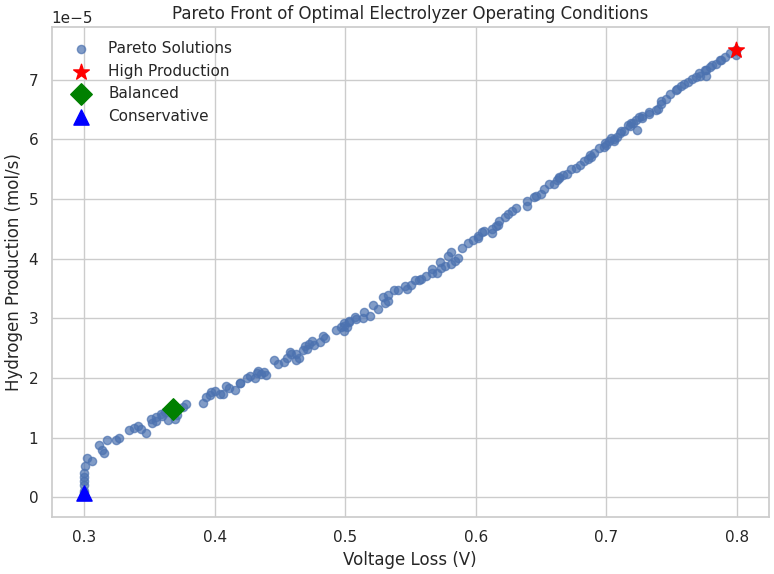

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    pareto_df["Voltage Loss"],
    pareto_df["H2"],
    alpha=0.7,
    s=35,
    label="Pareto Solutions"
)

plt.scatter(
    high_prod["Voltage Loss"],
    high_prod["H2"],
    color="red",
    s=140,
    marker="*",
    label="High Production"
)

plt.scatter(
    balanced["Voltage Loss"],
    balanced["H2"],
    color="green",
    s=120,
    marker="D",
    label="Balanced"
)

plt.scatter(
    conservative["Voltage Loss"],
    conservative["H2"],
    color="blue",
    s=120,
    marker="^",
    label="Conservative"
)

plt.xlabel("Voltage Loss (V)")
plt.ylabel("Hydrogen Production (mol/s)")
plt.title("Pareto Front of Optimal Electrolyzer Operating Conditions")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [118]:
import joblib

joblib.dump(gpr_h2, "gpr_h2.pkl")
joblib.dump(gpr_eff, "gpr_eff.pkl")
joblib.dump(gpr_vloss, "gpr_vloss.pkl")
joblib.dump(gpr_deg, "gpr_deg.pkl")

print("Models saved successfully!")

Models saved successfully!


In [119]:
pareto_df.to_csv("pareto_solutions.csv", index=False)
final_solutions.to_csv("optimal_operating_conditions.csv")

In [128]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate
import pandas as pd
import numpy as np
df = pd.read_excel("electrolyser_data.xlsx")
# -----------------------------
# Features
# -----------------------------
X = df[["Temperature", "Voltage", "Conductivity"]]

# -----------------------------
# Targets
# -----------------------------
targets = {
    "H₂ Production": "Faraday_H2_mol",
    "Efficiency": "Efficiency",
    "Voltage Loss": "Voltage_loss",
    "Degradation Index": "Degradation_index"
}

# -----------------------------
# 5-Fold CV
# -----------------------------
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

results = []

for name, target in targets.items():

    y = df[target]

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_validate(
        rf,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    results.append({
        "Target": name,
        "Mean R²": scores["test_R2"].mean(),
        "Std R²": scores["test_R2"].std(),
        "Mean MAE": -scores["test_MAE"].mean(),
        "Std MAE": scores["test_MAE"].std(),
        "Mean RMSE": -scores["test_RMSE"].mean(),
        "Std RMSE": scores["test_RMSE"].std()
    })

rf_cv_results = pd.DataFrame(results)

print("="*80)
print("Random Forest 5-Fold Cross Validation")
print("="*80)

display(rf_cv_results)

# Save for paper
rf_cv_results.to_csv("RF_5Fold_CV_Results.csv", index=False)

Random Forest 5-Fold Cross Validation


,Target,Mean R²,Std R²,Mean MAE,Std MAE,Mean RMSE,Std RMSE
0,H₂ Production,0.941820,0.054809,0.000002,2.464054e-07,0.000003,0.000001
1,Efficiency,0.999877,0.000040,0.000439,6.340447e-05,0.000603,0.000108
2,Voltage Loss,0.999892,0.000028,0.001070,1.393084e-04,0.001412,0.000201
3,Degradation Index,0.979549,0.003580,0.016328,8.403324e-04,0.022758,0.000829


In [123]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# =====================================================
# Training Features
# =====================================================

X_train = df[["Temperature","Voltage","Conductivity"]]

# =====================================================
# External Validation Features
# =====================================================

X_test = validation_df[["Temperature","Voltage","Conductivity"]]

# =====================================================
# Targets
# =====================================================

targets = {
    "H₂ Production": ("Faraday_H2_mol","Pred_RF_H2"),
    "Efficiency": ("Efficiency","Pred_RF_Efficiency"),
    "Voltage Loss": ("Voltage_loss","Pred_RF_VoltageLoss"),
    "Degradation Index": ("Degradation_index","Pred_RF_Degradation")
}

results = []

for target_name,(actual_col,pred_col) in targets.items():

    y_train = df[actual_col]

    # -----------------------------
    # Train RF
    # -----------------------------

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train,y_train)

    # -----------------------------
    # Predict External Data
    # -----------------------------

    prediction = rf.predict(X_test)

    validation_df[pred_col] = prediction

    # -----------------------------
    # Metrics
    # -----------------------------

    actual = validation_df[actual_col]

    r2 = r2_score(actual,prediction)

    mae = mean_absolute_error(actual,prediction)

    rmse = np.sqrt(mean_squared_error(actual,prediction))

    mask = actual != 0

    mape = np.mean(
        np.abs(
            (actual[mask]-prediction[mask])/
            actual[mask]
        )
    )*100

    results.append({
        "Target":target_name,
        "External R²":r2,
        "External MAE":mae,
        "External RMSE":rmse,
        "External MAPE (%)":mape
    })

# =====================================================
# Results
# =====================================================

rf_external_results = pd.DataFrame(results)

print("="*80)
print("Random Forest External Validation")
print("="*80)

display(rf_external_results)

rf_external_results.to_csv(
    "RF_External_Validation.csv",
    index=False
)

Random Forest External Validation


,Target,External R²,External MAE,External RMSE,External MAPE (%)
0,H₂ Production,0.951402,0.000002,0.000003,13.480015
1,Efficiency,0.999991,0.000138,0.000176,0.019729
2,Voltage Loss,0.999987,0.000412,0.000519,0.081171
3,Degradation Index,0.950368,0.032270,0.042833,12.626281


In [130]:
rf_external_results.to_csv('RFexternalmetrics.csv', index=False)
print("rf_external_results saved to 'RFexternalmetrics.csv' successfully.")

rf_external_results saved to 'RFexternalmetrics.csv' successfully.


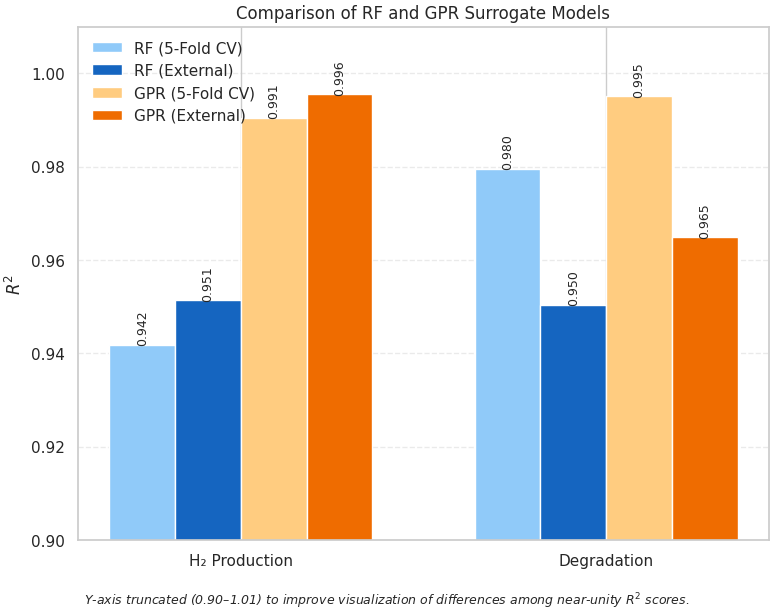

In [132]:
import matplotlib.pyplot as plt
import numpy as np

targets = ["H₂ Production", "Degradation"]

rf_cv = [0.9418, 0.9795]
gpr_cv = [0.9905, 0.9951]

rf_ext = [0.9514, 0.9504]
gpr_ext = [0.9955, 0.9649]

x = np.arange(len(targets))
w = 0.18

plt.figure(figsize=(8,6))

bars1 = plt.bar(x-1.5*w, rf_cv, width=w,
                color="#90CAF9",
                label="RF (5-Fold CV)")

bars2 = plt.bar(x-0.5*w, rf_ext, width=w,
                color="#1565C0",
                label="RF (External)")

bars3 = plt.bar(x+0.5*w, gpr_cv, width=w,
                color="#FFCC80",
                label="GPR (5-Fold CV)")

bars4 = plt.bar(x+1.5*w, gpr_ext, width=w,
                color="#EF6C00",
                label="GPR (External)")

for bars in [bars1,bars2,bars3,bars4]:
    for b in bars:
        plt.text(
            b.get_x()+b.get_width()/2,
            b.get_height()+0.0005,
            f"{b.get_height():.3f}",
            ha="center",
            fontsize=9,
            rotation=90
        )

plt.ylabel(r"$R^2$")
plt.xticks(x,targets)

plt.ylim(0.90,1.01)

plt.grid(axis='y',linestyle='--',alpha=0.4)

plt.legend()

plt.title("Comparison of RF and GPR Surrogate Models")

plt.figtext(
    0.5,
    -0.03,
    "Y-axis truncated (0.90–1.01) to improve visualization of differences among near-unity $R^2$ scores.",
    ha="center",
    fontsize=9,
    style="italic"
)

plt.tight_layout()

plt.savefig(
    "RF_vs_GPR_R2.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()